In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from collections import Counter
import scipy.stats as ss
import matplotlib.dates as mpldates

%matplotlib inline
import pymc
import arviz as az
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


#### Executive Summary

Living in the big city can offer many amenities by virtue of the larger population and the resources available to an individual. We recently moved to Chicago from Lincoln, Nebraska and were overwhelmed by the range of "things" in the city. Rather than a rather flat monoculture, every neighborhood had its own unique personality, and there was a wide range of people from different backgrounds to meet. However, whenever people gather in concentration, frictions can arise and bad behaviors can be encouraged by the sheer number of opportunities that present themselves to a dishonest individual every day. Understanding crime patterns can be essential for safety, resource planning, and policy decision making. 

#### Problem Statement

We seek to investigate the LA Crimes data set to better understand trends over time, especially post COVID, trends over locations across different neighborhoods, and relationships between crime types, time of day, time of year, and other factors. Insights can help law enforcement focus resources in the right areas. Policemen (and everyone living in the city) have a feel for which areas are more dangerous, but we can formalize these feelings with hard data based on reporting statistics. Additionally, this data includes demographic information. A hot topic is disproportionate police response to different races, and hopefully we can uncover some of the relationships here to see if there is indeed a discrepancy.

One of the main shortfalls of crime data is that the information is collected through the lens of those reporting the crime, often police officers. This introduces problems with missing data, hastily prepared reports, or inaccuracies. But this also introduces biases from police officers, who may underreport crimes committed in certain neighborhoods, by certain demographics, whether age or race or another statistic. 

Our goal is to see what insights we can pull from this crime data set, to see if we could potentially Minority Report-style predict crimes and plan accordingly, and to see if there are biases present in crime reporting in general.

#### Data Preparation and Description
Data was downloaded from [this page on data.gov](https://catalog.data.gov/dataset/crime-data-from-2020-to-present) and metadata was sourced from [this page at lacity.org](https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-Present/2nrs-mtv8/about_data). The data is a record of over 1 million crimes committed and logged in LA from 2020 onwards. There are 28 columns, with instance ID, date, time, location, description of the crime, and some other variables.

In [2]:
## Full Data Set (Originally Downloaded Nov 13, 2025)
lacrime = pd.read_csv("../axproj/Crime_Data_from_2020_to_Present.csv", 
                 low_memory =False,
                 parse_dates = ["Date Rptd", "DATE OCC"] ) ## Full Data Set

## Metadata from LACity.org 
MO_codes = pd.read_csv("../axproj/MO_Codes_Numerical.csv")  ## Modus Operandi codes

map_desc = dict( ## meta_data map for victim descent
    A="Other Asian", B="Black", C="Chinese", D="Cambodian",
    F="Filipino", G="Guamanian", H="Hispanic/Latin/Mexican",
    I="American Indian/Alaskan Native", J="Japanese", K="Korean",
    L="Laotian", O="Other", P="Pacific Islander", S="Samoan",
    U="Hawaiian", V="Vietnamese", W="White", X="Unknown",
    Z="Asian Indian"
)


/var/folders/d0/01t2y6qs1dn8z3g5krcgkc_00000gn/T/ipykernel_84153/1288054704.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  lacrime = pd.read_csv("../axproj/Crime_Data_from_2020_to_Present.csv",
/var/folders/d0/01t2y6qs1dn8z3g5krcgkc_00000gn/T/ipykernel_84153/1288054704.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  lacrime = pd.read_csv("../axproj/Crime_Data_from_2020_to_Present.csv",


In [3]:
lacrime.shape

(1004991, 28)

In [4]:
lacrime.dtypes

DR_NO                      int64
Date Rptd         datetime64[ns]
DATE OCC          datetime64[ns]
TIME OCC                   int64
AREA                       int64
AREA NAME                 object
Rpt Dist No                int64
Part 1-2                   int64
Crm Cd                     int64
Crm Cd Desc               object
Mocodes                   object
Vict Age                   int64
Vict Sex                  object
Vict Descent              object
Premis Cd                float64
Premis Desc               object
Weapon Used Cd           float64
Weapon Desc               object
Status                    object
Status Desc               object
Crm Cd 1                 float64
Crm Cd 2                 float64
Crm Cd 3                 float64
Crm Cd 4                 float64
LOCATION                  object
Cross Street              object
LAT                      float64
LON                      float64
dtype: object

In [5]:
lacrime['Mocodes'].unique()

array(['0377', '0416 0334 2004 1822 1414 0305 0319 0400', '0344', ...,
       '0216 0334 0371 0906', '0400 1822 1310 0416',
       '2047 0400 0429 0444 1202 1822'], dtype=object)

#### Data clean up and preparation
In preparation, we clean up some of the time data formatting and add in indicators or nulls where data is unavailable. As this data is dependent on manual entry, missing or default values can cause issues in further analysis. For example, there are no crimes committed by people of age 0 (I hope). 

In data clean up (subject to do more):
* Standardize time to a 4 digit string
* Add in metrics for hour, minute, month, and day
* Cast time to a float number that we can run regressions on
* Include missing indicators for locations registered as 0, 0 because LA exists in a specific latitude and longitude
* Remove 0 values from age

We add some potential regression variables (subject to add more):
* report_delay - the delay between the time a crime was reported and when it occurred
* severity - a 1 to 3 score, based on whether the crime was Part 1 (score 2) or Part 2 (score 1), with an extra +1 if a weapon was recorded. Part 1 crimes include violent and property crimes, while part 2 encompass just about everything else, like vandalism and drug offenses
* area_score - a daily count per area
* complexity - a count of the number of Crime Codes associated with each crime. This is subject to manual entry decisions, but we could potentially uncover reporting consistency issues

In [6]:
# clean up function
def clean_lacrime(df):
    df = df.copy() 

    df['TIME OCC'] = df['TIME OCC'].astype(str).str.zfill(4) # standardize time
    df['hour'] = df['TIME OCC'].str[:2].astype(int)
    df['minute'] = df['TIME OCC'].str[2:].astype(int)
    df['time_float'] = df['hour'] + df['minute']/60.0
    df['month'] = df['DATE OCC'].dt.month
    df['day'] = df['DATE OCC'].dt.day
    df['year'] = df['DATE OCC'].dt.year
    # df['week_of_year'] = df['DATE OCC'].dt.isocalendar().week
 
    df['loc_missing'] = ((df['LAT'] == 0) & (df['LON'] == 0)).astype(int) # missing loc indicator
    df['Vict Age'] = df['Vict Age'].replace(0, np.nan) # clean missing age victim

    df['LAT_std'] = (df['LAT'] - df['LAT'].mean()) / df['LAT'].std() # standardize location
    df['LON_std'] = (df['LON'] - df['LON'].mean()) / df['LON'].std()

    # deal with blanks in weapon codes and mocodes
    df['Weapon Used Cd'] = df['Weapon Used Cd'].fillna(0)
    df['Weapon Desc'] = df['Weapon Desc'].fillna("n/a")
    
    # fill in empty mocodes with 0000 instead of 'na'
    df['Mocodes'] = df['Mocodes'].fillna("0000") 
    
    # removing spaces from some variables
    df['AREA'] = df['AREA NAME']
    df['vDescent'] = df['Vict Descent']

    # add a sequential month and sequential year
    df['month_seq'] = (df['year'] - df['year'].min()) * 12 + df['month']
    df['week_seq'] = ((df['DATE OCC'] - df['DATE OCC'].min()).dt.days // 7) + 1

    return df

# potential regression targets
def add_regression_vars(df):
    df = df.copy()
    df['report_delay'] = (df['Date Rptd'] - df['DATE OCC']).dt.days # delay in reporting
    df['weapon_cd'] = df['Weapon Used Cd'].fillna(0) # fill in 0s when weapon code is n
    df['severity'] = 3 - (df['Part 1-2'] + np.where(df['weapon_cd'] > 0, -1, 0)) # 1,2,3 severity scale based on weapon usage and Part 1-2
    df['area_score'] = df.groupby(['AREA', 'DATE OCC']).transform('size') # count per area per day , use transform to index correctly
    df['complexity'] = df[['Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4']].notnull().sum(axis = 1) # crime complexity based on number of codes
    return df


In [7]:
def series_center(series):
    return series - series.mean()
def series_center_z(series):
    return (series - series.mean())/(series.std())


def plotQQ(series):
    fig, ax = plt.subplots(figsize=(8, 8))
    ss.probplot(series, plot=ax)
    ax.axhline(0, color='gray', linestyle='--')
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_xlim(-3, 3)
    ax.set_ylim(series.min(), series.max())


def clean_nan(df):
    cols = ['Vict Age', 'Premis Desc', 'Status']
    df = df.dropna(subset=cols)
    df = df[df['DATE OCC'].dt.year < 2024]
    return df

# convert sequential week back to a date
def week_seq_to_date(week_seq, start_date = '2020-01-01'):
    start_date = datetime.strptime(start_date, '%Y-%m-%d').date()
    days_diff = (week_seq - 1) * 7
    return start_date + timedelta(days = days_diff)

def month_seq_to_date(month_seq, start_date = '2020-01-01'):
    start_date = datetime.strptime(start_date, '%Y-%m-%d').date()
    return start_date + relativedelta(months = month_seq - 1)  


In [8]:
lacrime = clean_lacrime(lacrime)
lacrime = add_regression_vars(lacrime)
lacrime = clean_nan(lacrime)
# create dataframe of weapon usage
distinct_weapons = lacrime[['weapon_cd', 'Weapon Desc']].drop_duplicates()

In [9]:
lacrime.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON', 'hour', 'minute', 'time_float', 'month', 'day', 'year',
       'loc_missing', 'LAT_std', 'LON_std', 'vDescent', 'month_seq',
       'week_seq', 'report_delay', 'weapon_cd', 'severity', 'area_score',
       'complexity'],
      dtype='object')

In [10]:
# create sample for excel look
sample = lacrime.head(10)
sample.to_csv("../axproj/sample2.csv")

#### EDA - Distributions

/var/folders/d0/01t2y6qs1dn8z3g5krcgkc_00000gn/T/ipykernel_84153/1735788083.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _=ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


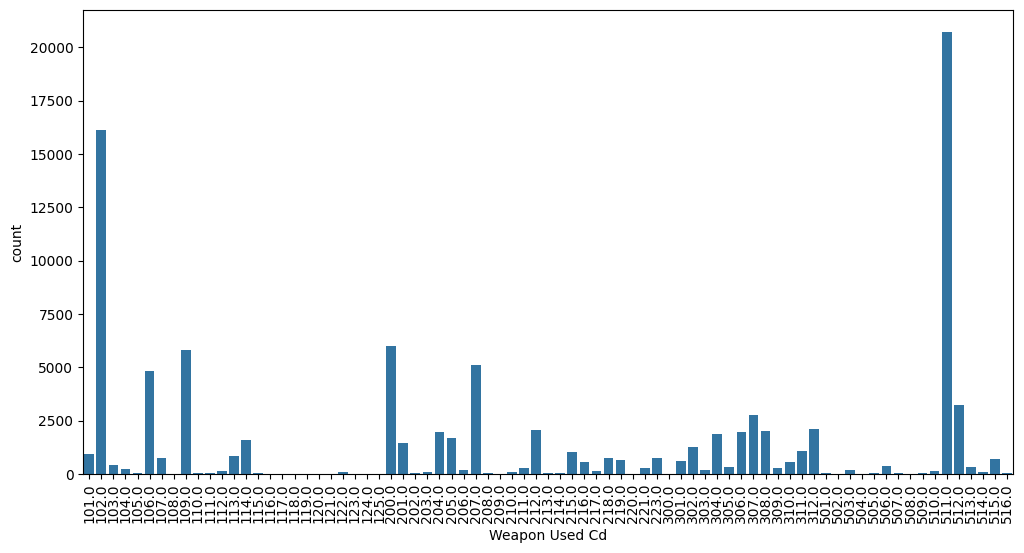

In [11]:
fig, ax = plt.subplots(figsize = (12, 8))
fig.subplots_adjust(bottom = 0.3)
# ax = sns.countplot(x = 'hour', data = lacrime, ax = ax)
sns.countplot(x = 'Weapon Used Cd', data = lacrime[~lacrime['Weapon Used Cd'].isin([0, 400, 500])], ax = ax)
_=ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

Grouping: We should group categories by the 7 most common, then an 8th catch-all, unless we can find groupings for each of these.

In [12]:
# weapon_used = lacrime['Weapon Desc'].value_counts().head(5)
twc = lacrime['Weapon Used Cd'].value_counts().head(20)
lacrime[lacrime['Weapon Used Cd'].isin(twc.index)].groupby(['Weapon Used Cd', 'Weapon Desc']).size().sort_values(ascending = False)

Weapon Used Cd  Weapon Desc                                   
0.0             n/a                                               379522
400.0           STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)    154602
500.0           UNKNOWN WEAPON/OTHER WEAPON                        28126
511.0           VERBAL THREAT                                      20719
102.0           HAND GUN                                           16148
200.0           KNIFE WITH BLADE 6INCHES OR LESS                    6012
109.0           SEMI-AUTOMATIC PISTOL                               5822
207.0           OTHER KNIFE                                         5097
106.0           UNKNOWN FIREARM                                     4834
512.0           MACE/PEPPER SPRAY                                   3237
307.0           VEHICLE                                             2768
312.0           PIPE/METAL PIPE                                     2094
212.0           BOTTLE                                       

In [13]:
twc.index

Index([  0.0, 400.0, 500.0, 511.0, 102.0, 200.0, 109.0, 207.0, 106.0, 512.0,
       307.0, 312.0, 212.0, 308.0, 306.0, 204.0, 304.0, 205.0, 114.0, 201.0],
      dtype='float64', name='Weapon Used Cd')

In [14]:
premis = lacrime['Premis Desc'].value_counts().head(20)
premis

Premis Desc
SINGLE FAMILY DWELLING                          146391
STREET                                          121140
MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)    103083
PARKING LOT                                      42006
SIDEWALK                                         35014
VEHICLE, PASSENGER/TRUCK                         24206
OTHER BUSINESS                                   20588
GARAGE/CARPORT                                   12999
DRIVEWAY                                         10152
PARKING UNDERGROUND/BUILDING                      6467
RESTAURANT/FAST FOOD                              6268
OTHER RESIDENCE                                   5878
OTHER PREMISE                                     5411
ALLEY                                             5166
PARK/PLAYGROUND                                   4863
YARD (RESIDENTIAL/BUSINESS)                       4776
DEPARTMENT STORE                                  4533
HOTEL                                             425

In [15]:
premises = lacrime['Premis Desc'].astype(str).drop_duplicates().sort_values()
premises.shape
premises

86258     7TH AND METRO CENTER (NOT LINE SPECIFIC)
1497            ABANDONED BUILDING ABANDONED HOUSE
116857                          ABATEMENT LOCATION
120411          ABORTION CLINIC/ABORTION FACILITY*
39925                                     AIRCRAFT
                            ...                   
12413                        VISION CARE FACILITY*
472                                      WAREHOUSE
4304                                WATER FACILITY
1030                                       WEBSITE
7                      YARD (RESIDENTIAL/BUSINESS)
Name: Premis Desc, Length: 303, dtype: object

In [16]:
# lacrime[lacrime['Premis Desc'].isna()].shape
# lacrime[['Status', 'Status Desc']].value_counts().head(10)
lacrime[lacrime['AREA'].isna()]

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,LAT_std,LON_std,vDescent,month_seq,week_seq,report_delay,weapon_cd,severity,area_score,complexity


In [17]:
lacrime['Premis Desc'].astype(str).value_counts().head(20)

Premis Desc
SINGLE FAMILY DWELLING                          146391
STREET                                          121140
MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)    103083
PARKING LOT                                      42006
SIDEWALK                                         35014
VEHICLE, PASSENGER/TRUCK                         24206
OTHER BUSINESS                                   20588
GARAGE/CARPORT                                   12999
DRIVEWAY                                         10152
PARKING UNDERGROUND/BUILDING                      6467
RESTAURANT/FAST FOOD                              6268
OTHER RESIDENCE                                   5878
OTHER PREMISE                                     5411
ALLEY                                             5166
PARK/PLAYGROUND                                   4863
YARD (RESIDENTIAL/BUSINESS)                       4776
DEPARTMENT STORE                                  4533
HOTEL                                             425

/var/folders/d0/01t2y6qs1dn8z3g5krcgkc_00000gn/T/ipykernel_84153/3788664160.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _=ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


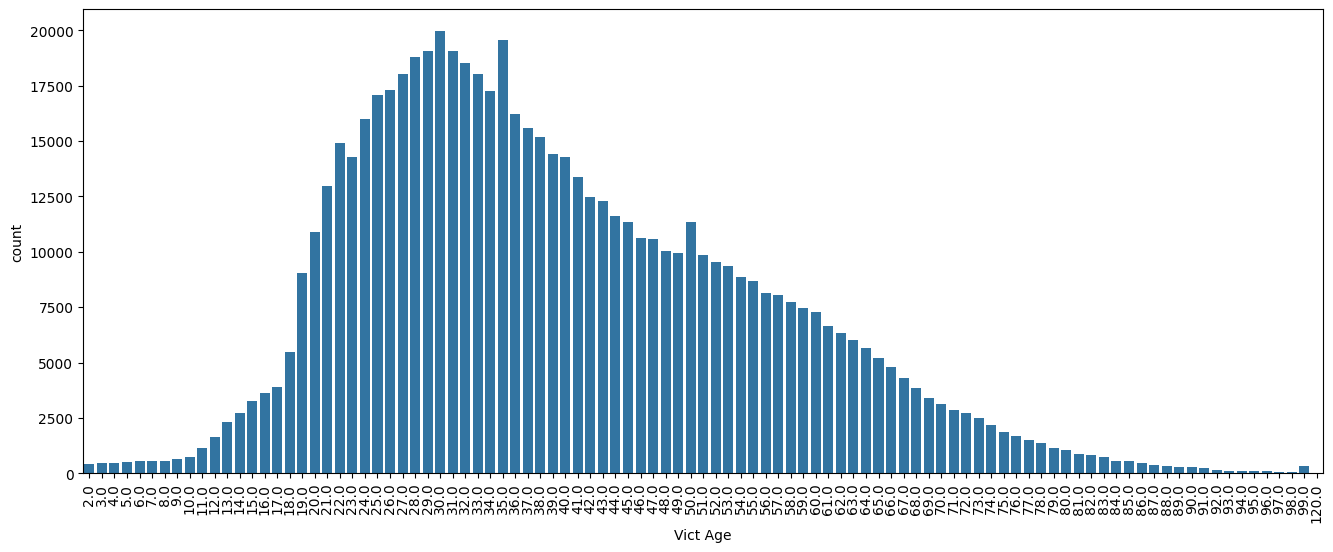

In [18]:
fig, ax = plt.subplots(figsize = (16, 8))
fig.subplots_adjust(bottom = 0.3)
# ax = sns.countplot(x = 'hour', data = lacrime, ax = ax)
sns.countplot(x = 'Vict Age', data = lacrime[lacrime['Vict Age'] > 0], ax = ax)
_=ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
#35 year old seems to be the most common


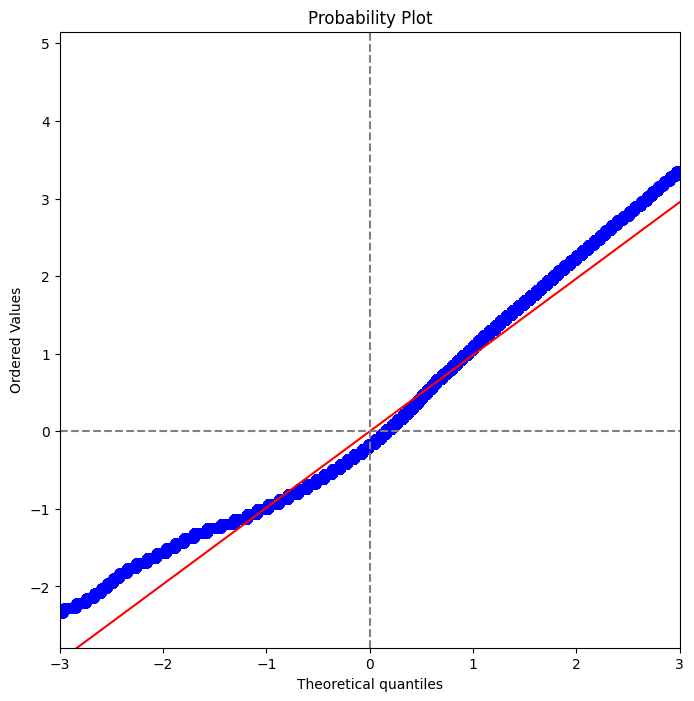

In [19]:
# plotQQ(series_center_z(lacrime['Vict Age'][~lacrime['Vict Age'].isna()]))
plotQQ(series_center_z(lacrime['Vict Age']))
# series_center_z(lacrime['Vict Age']).max()

In [20]:
lacrime['Vict Sex'].value_counts()

Vict Sex
M    331492
F    318836
X      8215
H        95
Name: count, dtype: int64

In [21]:
nomo = lacrime[['DR_NO','Mocodes']][lacrime['Mocodes'].isna()].head(5)
# lacrime[lacrime['DR_NO'].isin(nomo['DR_NO'])]['Mocodes']

In [22]:
lacrime['Mocodes'].head(10)

mo_lists = lacrime['Mocodes'].astype(str).str.split()
all_codes = mo_lists.explode()
# mo_lists.head()
# all_codes
mo_counts = all_codes.value_counts().reset_index()
# mo_counts.head(5)
mo_counts['Mocodes'] = mo_counts['Mocodes'].fillna(0).replace('nan',0)
# mo_counts
mo_counts['MO_code'] = mo_counts['Mocodes'].astype(int)
mo_counts_with_desc = mo_counts.merge(
    MO_codes,
    left_on='MO_code',
    right_on = 'MO_code',
    how = 'left'
)

mo_counts_with_desc.sort_values(by = 'count', ascending = False).head(15)


,Mocodes,count,MO_code,MO_desc
0,1822,255948,1822,Stranger
1,0344,221074,344,Removes vict property
2,0913,137826,913,Victim knew Suspect
3,0416,109471,416,Hit-Hit w/ weapon
4,0329,91195,329,Vandalized
5,1300,78000,1300,Vehicle involved
6,2000,68596,2000,Domestic violence
7,0400,64570,400,Force used
8,1814,43945,1814,Susp is/was current/former boyfriend/girlfriend
9,1402,41563,1402,Evidence Booked (any crime)


In [23]:
lacrime['Mocodes'].fillna("0000").value_counts(dropna = False).head(5)

Mocodes
0344         30067
0329         14055
1822 0344    10207
0344 1822     6655
1501          6169
Name: count, dtype: int64

In [24]:
# lacrime['Date Rptd'].max()

#### EDA
##### Daily Volume
First, we take a look at the daily reporting volume. This is obviously time series data, and it's pretty obvious we can see some seasonality, especially per month. When we look at the crimes occuring by day of month, there is a heavy weight towards the beginning of the month. This could be due to meeting reporting quotas or perhaps a natural response to crimes committed to meet bills at the end of the month. More likely, first of the month is probably just the default reporting value when the reporter cannot remember the specific day that a crime happened.

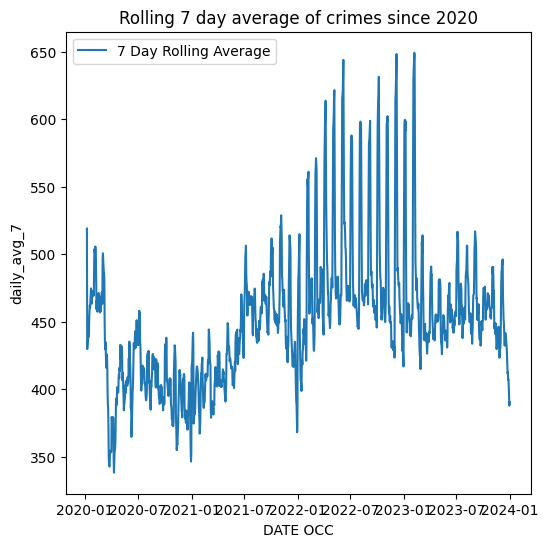

In [25]:
## daily volume
# shows serious potential reporting errors in data set - potentially remove time series data based on seasonality
daily_crimes = lacrime.groupby('DATE OCC').size().reset_index(name = 'crime_count')
plt.figure(figsize = (6,6))
daily_crimes['daily_avg_7'] = daily_crimes['crime_count'].rolling(7).mean()
sns.lineplot(data = daily_crimes, x = 'DATE OCC', y = 'daily_avg_7', label = '7 Day Rolling Average')
plt.title('Rolling 7 day average of crimes since 2020')
plt.show()

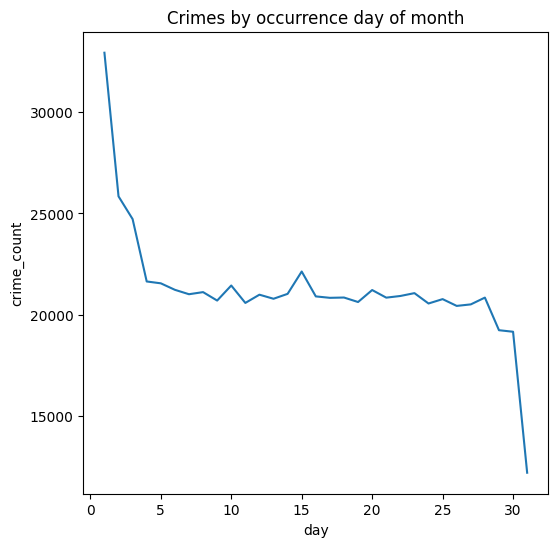

In [26]:
day_of_month_crimes = lacrime.groupby('day').size().reset_index(name = 'crime_count')
plt.figure(figsize = (6,6))
sns.lineplot(data = day_of_month_crimes, x = 'day', y = 'crime_count')
plt.title('Crimes by occurrence day of month')
plt.show()

##### Daily Crimes By Area
Looking at number of daily crimes by area, there is too much noise for us to visualize properly. However, just looking at the total count of crimes, we can see that there are definitely higher crime areas. We explore this further down the page.

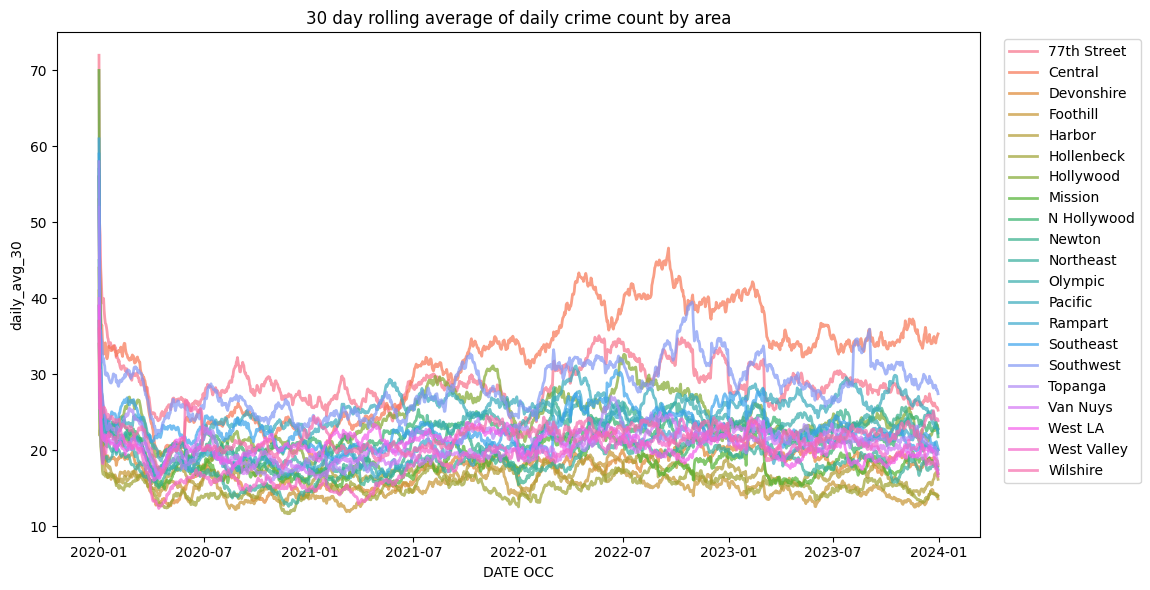

In [27]:
## rolling 30 daily volume by area. probably needs more development before it is useful
daily_crimes_area = lacrime.groupby(['DATE OCC', 'AREA NAME']).size().reset_index(name = 'crime_count')
daily_crimes_area['daily_avg_30'] = daily_crimes_area.sort_values(['AREA NAME', 'DATE OCC']).groupby('AREA NAME')['crime_count'].transform(lambda x: x.rolling(30, min_periods=1).mean())
plt.figure(figsize=(10,6))
ax = sns.lineplot(data = daily_crimes_area, x = 'DATE OCC', y = 'daily_avg_30', hue = 'AREA NAME', linewidth = 2, alpha = 0.7)
plt.title('30 day rolling average of daily crime count by area')
plt.tight_layout()
ax.legend(loc = 'upper center', bbox_to_anchor=(1.1,1))

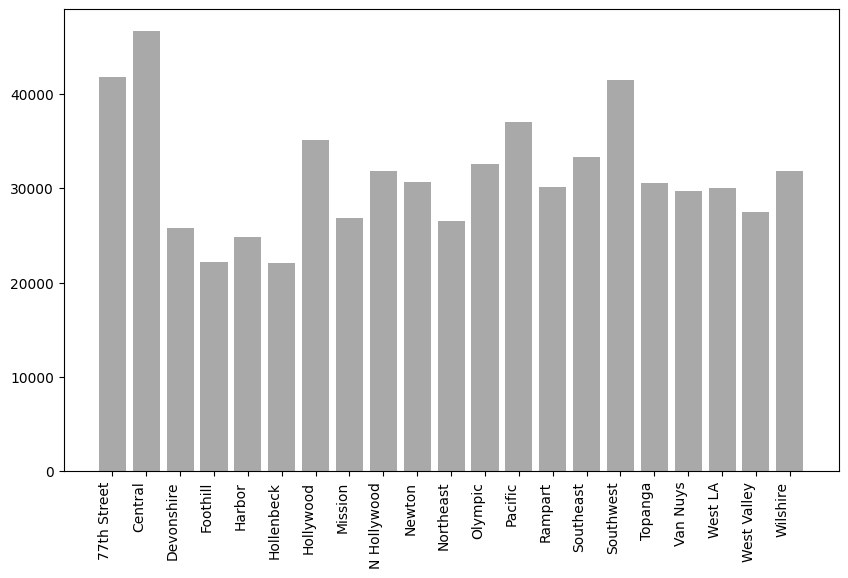

In [28]:
## show total crimes by area
crimes_area = lacrime.groupby(['AREA NAME']).size().reset_index(name = 'crime_count')
plt.figure(figsize=(10,6))
plt.bar(crimes_area['AREA NAME'],crimes_area['crime_count'], color = 'darkgrey')
plt.xticks(rotation = 90, ha='right')
plt.show()

##### Time of day vs type of crime
We restrict to the top 8 most common crimes, then evaluate what time of day they each occur. Identity theft has the most obvious trend, but it's more likely that reporters are putting in default values, as identity theft is probably harder to pinpoint the exact hour of as the victim doesn't always know immediately when their identity has been compromised. However, the more serious crimes such as assault, burglary, and vehicle theft seem to happen later in the night, which matches our common intuition. We could potentially predict the type of crime with other factors included in, such as area (perhaps latitude, longitude), day of month, etc. 

Text(0.5, 1.0, 'Day of time occurrence for top 8 crimes in LA')

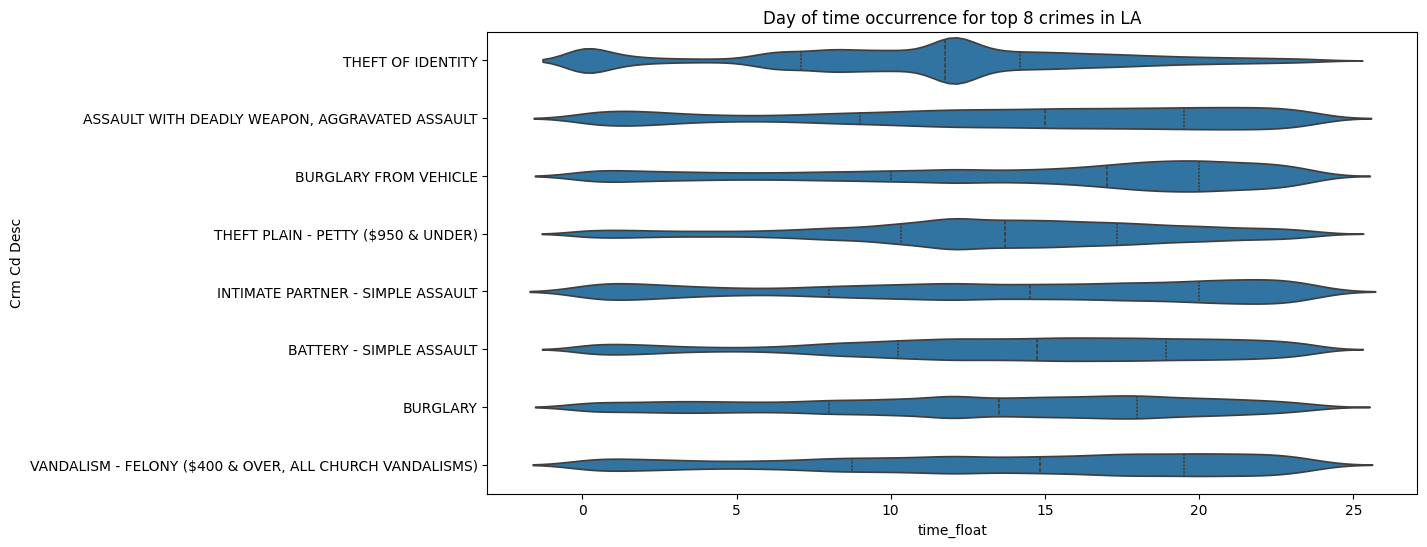

In [29]:
top_crimes = lacrime['Crm Cd Desc'].value_counts().head(8).index
toplacrime = lacrime[lacrime['Crm Cd Desc'].isin(top_crimes)]
plt.figure(figsize=(12,6))
sns.violinplot(data= toplacrime, y = 'Crm Cd Desc', x = 'time_float', inner ='quartile')
plt.title('Day of time occurrence for top 8 crimes in LA')

In [30]:
toplacrimegroup = toplacrime.groupby(['month','Crm Cd Desc'])['DR_NO'].count().reset_index()
toplacrimegroup.head(5)

,month,Crm Cd Desc,DR_NO
0,1,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",3527
1,1,BATTERY - SIMPLE ASSAULT,5455
2,1,BURGLARY,3034
3,1,BURGLARY FROM VEHICLE,4991
4,1,INTIMATE PARTNER - SIMPLE ASSAULT,3549


##### Time of month against time of day
Continuing the previous analysis, we look at time of month against time of day. First of all, there is a clear trend that crimes seem to happen at noon, but this is likely due to a reporting quirk. Ignoring this data point, we can see that crimes happen more at night, around 6-7 pm in the evening. There is a clear decline in crime reporting in the early hours of the morning, but, again, this could be a reporting issue rather than actual crime statistics.

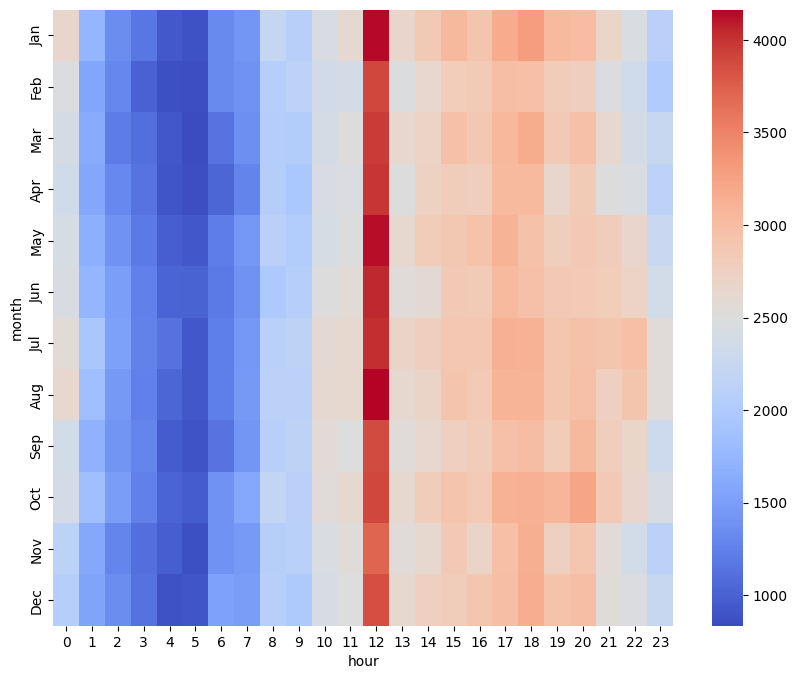

In [31]:
crimehours = lacrime.groupby(['month','hour'])['DR_NO'].count().reset_index()
crimehoursheat = crimehours.pivot(index = 'month', columns = 'hour', values = 'DR_NO')
crimehoursheat.index = crimehoursheat.index.map(lambda x: calendar.month_abbr[x])
fig,ax = plt.subplots(figsize=(10,8))
ax = sns.heatmap(crimehoursheat,cmap='coolwarm', ax = ax)
# implies heavily that a lot of data doesn't have a time, or officers are just putting in 0:00 or something along those lines

##### Analysis of Area
Looking at area as categorical data, there are obvious hot spots of crime. We removed the outliers from displaying in the box and whisker plot for now. We can cross reference this with latitude/longitudinal data to see which areas of each neighborhood are potentially the most dangerous or highest crime. Neighborhoods also have unique demographics, which could lend insight into police treatment. We should also look at the type of crime by area, perhaps "safer" areas could contradictorily be safe because of heavier policing and more minor crimes being charged.

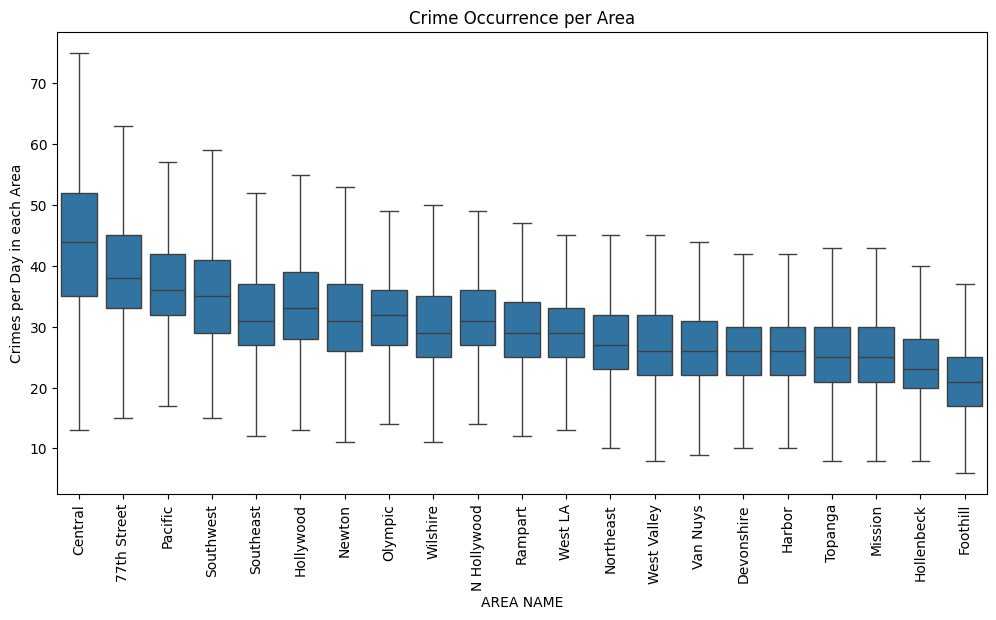

In [32]:
plt.figure(figsize = (12,6))
area_order = lacrime.groupby('AREA NAME')['area_score'].mean().sort_values(ascending=False).index
sns.boxplot(data=lacrime, x='AREA NAME', y='area_score', order = area_order, showfliers = False)
# sns.boxplot(data=lacrime, x='AREA NAME', y='area_score', showfliers = True)
# sns.boxplot(data=lacrime[lacrime['AREA NAME'] != 'Wilshire'], x='AREA NAME', y='area_score')
plt.xticks(rotation=90)
plt.title("Crime Occurrence per Area")
plt.ylabel("Crimes per Day in each Area")
plt.show()


##### Crime severity vs number of charges
Our easiest measure for crime severity is just categorization of weapon usage and Part 1 vs Part 2 crimes. Here we can see a relationship between the number of crime codes and the severity of the crime charged. Part 1 and Part 2 crimes encompass crime codes as well, Part 1 being the more serious crimes like violent assault, etc. We could attempt to simply parse the text for certain keywords and revisit severity that way. 

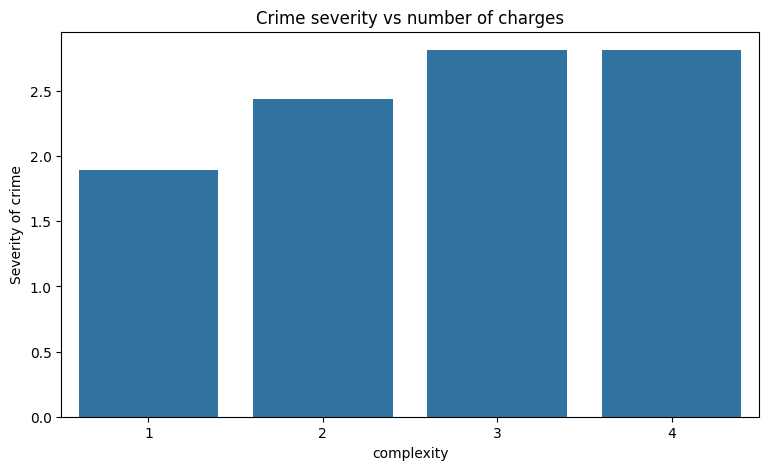

In [33]:
plt.figure(figsize=(9,5))
sns.barplot(data=lacrime, x = 'complexity', y = 'severity', errorbar = None)
plt.title("Crime severity vs number of charges")
plt.ylabel("Severity of crime")
plt.show()

##### Correlation matrix
There are no obvious trends from our correlation matrix, which is probably to be expected with the coarse treatment of our variables. Severity is binned in 3, complexity is also binned in 4. There are no clear linear relationships between these variables, so we can immediately conclude that single variable OLS is probably out of the picture. However, there is potential in looking at crime complexity against severity, but as stated above, these large bins would require more finesse in understanding.

<Axes: >

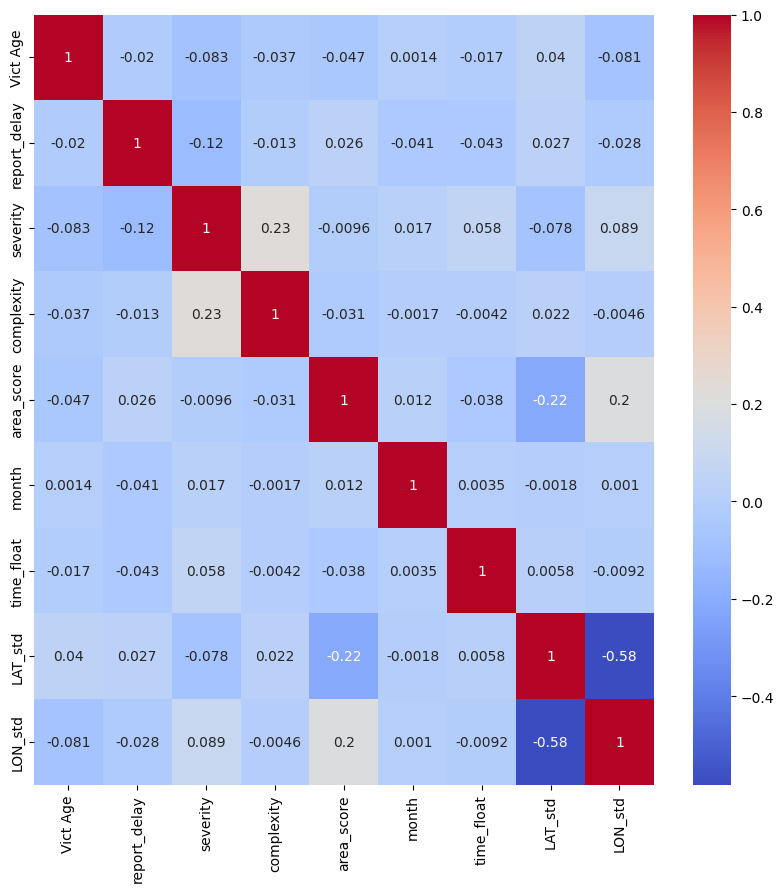

In [34]:
corrcols = [
    'Vict Age',
    'report_delay',
    'severity',
    'complexity',
    'area_score',
    'month',
    'time_float',
    'LAT_std',
    'LON_std'
]
corr_mat = lacrime[lacrime['loc_missing']!= 1][corrcols].corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_mat,annot=True,cmap ='coolwarm')

#### Data issues
Just from a very cursory analysis of the data, there are several issues that we will have to deal with, not limited to:
* Reporting issues - There are 0s in latitude, longitude, age. There is a clear trend in crimes occurring in the beginning of the month, way more than is to be expected. In addition, there is a clear dropoff in crimes in 2024/2025 that does seems artificial. In dealing with this data, we will need to understand all the reporting errors that can occur and clean more thoroughly.
* This may hve been wishful thinking, but our only strong correlations area in latitude and longitude (which makes sense based on the shape of Los Angeles stretching northwest to southeast along the coast of Southern California).  
* The data is messy overall and potentially incomplete: Crime code descriptions and weapon descriptions are in text, which will require some extraction. A lot of the codes will require external sources, such as Vict Descent and Mocodes (modus operandi), which have been loaded in, but there may be others required.

#### Basic analytics

##### Severity
We run a simple linear regression. The linear regression actually shows p-values that imply that nearly all of our variables are significant. However, their magnitude is quite low, and our R^2 of .303 is poor. The model could potentially be refined by adding in more variables (we only used 6 of 27).

In [35]:
df = lacrime.dropna(subset=['severity', 'report_delay', 'weapon_cd', 'hour', 'complexity', 'AREA', 'vDescent'])

model = smf.ols(
    formula='severity ~ report_delay + weapon_cd + hour + complexity + C(AREA) + C(vDescent)',
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               severity   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     6932.
Date:                Sat, 13 Dec 2025   Prob (F-statistic):               0.00
Time:                        01:18:18   Log-Likelihood:            -5.3637e+05
No. Observations:              658639   AIC:                         1.073e+06
Df Residuals:                  658595   BIC:                         1.073e+06
Df Model:                          43                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

##### Fitting SARIMAX to time series data
Investigating just one area (Central) with a SARIMAX, with (p,d,q) = (1,1,1) and (P,D,Q,s) = (1,1,1,7). We are investigating the difference in crimes from day to day. Note, I did not use the hyperparameter search, just a simple order for the first exploratory analysis. However, we still got interesting results: Our ma.L1 statistic says that the previous day's shock is canceled out each day's. Our seasonal term of ma.S.L7 shows that the shock from a week ago strongly affects the given day, but there is a correction back from the previous week's shock.

Looking at our predicted values, there is a decent fit when just restricted to January 2022. 

Our overall model behavior still has unaccounted for biases: heteroskedasticity is high so our residuals splay. We have a high p-value in the Ljung-Box test, so we fail to reject the null of autocorrelation. This seems to fit intuition. Our JB test shows residuals are non-normal, which is not unexpected. Ultimately our log-likelihood of -6e3 indicates a reasonable fit given the amount of data present. Our conclusion here is that SARIMAX captured some of the short term and weekly patterns, but we would need to do more data cleaning and refinement, especially dealing with the residual heteroskedasticity and lack of normality.

/Users/alanxu/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/alanxu/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                       crime_count   No. Observations:                 1461
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -4880.768
Date:                           Sat, 13 Dec 2025   AIC                           9771.536
Time:                                   01:18:20   BIC                           9797.911
Sample:                               01-01-2020   HQIC                          9781.380
                                    - 12-31-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1137      0.026      4.312      0.000       0.062       0.165
ma.L1         -0.9398      0.010    -92.173

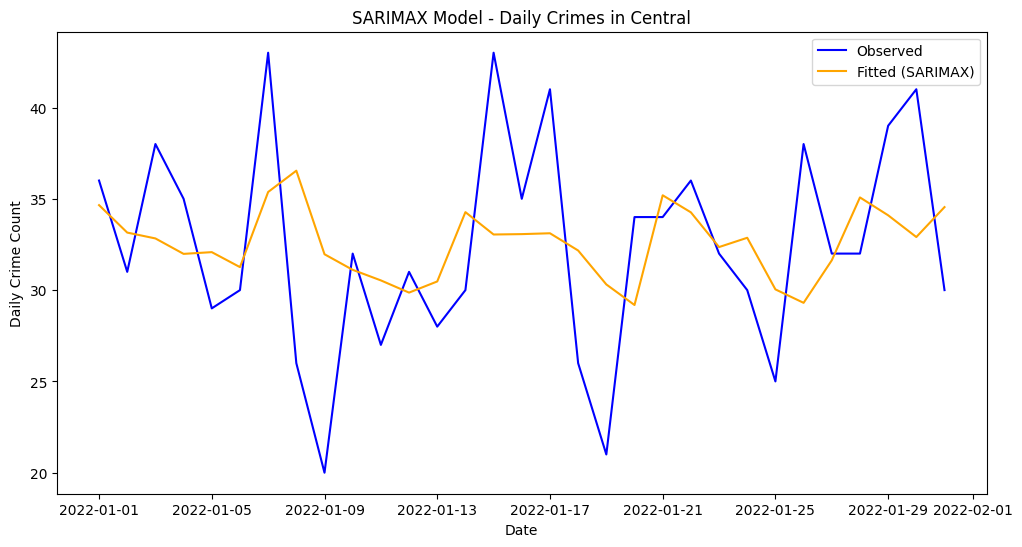

In [36]:
daily_area = lacrime.groupby(['DATE OCC', 'AREA']).size().reset_index(name='crime_count')

## use Central as example (highest mean)
area_name = 'Central'
ts = daily_area[daily_area['AREA']==area_name].set_index('DATE OCC').sort_index()


# Fit SARIMAX
model = SARIMAX(
    ts['crime_count'],
    order=(1,1,1), # ARIMA(1,1,1)
    seasonal_order=(1,1,1,7),  # weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_result = model.fit(disp=False)
print(sarimax_result.summary())

ts['pred'] = sarimax_result.fittedvalues
ts_2022 = ts[(ts.index.year == 2022) & (ts.index.month == 1)]

plt.figure(figsize=(12,6))
plt.plot(ts_2022.index, ts_2022['crime_count'], label='Observed', color='blue')
plt.plot(ts_2022.index, ts_2022['pred'], label='Fitted (SARIMAX)', color='orange')
plt.title(f"SARIMAX Model - Daily Crimes in {area_name}")
plt.xlabel('Date')
plt.ylabel('Daily Crime Count')
plt.legend()
plt.show()

#### Question 1: Did violent crime increase or decrease after 2020?

In [37]:
lacrime['severity'].value_counts()

severity
2    370573
1    164498
3    123597
Name: count, dtype: int64

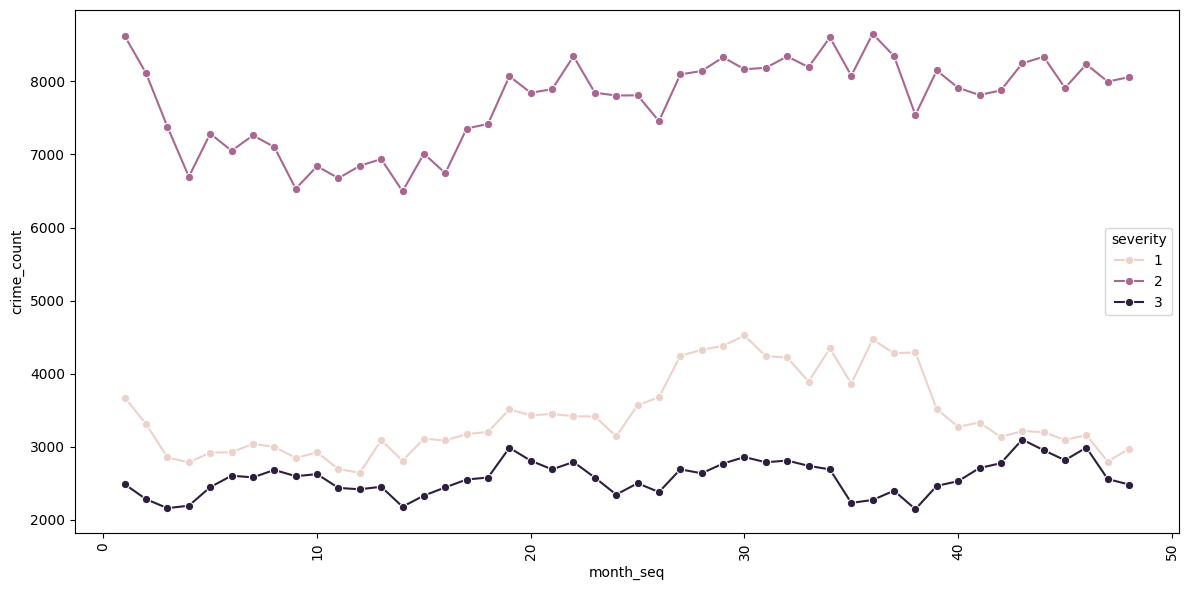

In [38]:
monthly_plot = lacrime.groupby([pd.Grouper(key = 'month_seq'), 'severity']).size().reset_index(name = 'crime_count')
fig,ax = plt.subplots(figsize = (12,6))
sns.lineplot(data = monthly_plot, x = 'month_seq', y = 'crime_count', hue = 'severity',marker = 'o',  ax = ax)
# _=ax.set_xticks(60)
# ax.xaxis.set_major_locator(mpldates.MonthLocator(interval = 3))
# ax.xaxis.set_major_formatter(mpldates.DateFormatter('%Y-%m'))

plt.setp(ax.get_xticklabels(), rotation = 90)

plt.tight_layout()

A basic look at this chart shows an increasing trend. It makes intuitive sense, given the lockdown period prevented people from being outside and reporting crimes. Let's see if we can understand this more clearly, and perhaps find a split point when the crime rate rose back up after lockdown. Remember that severity is coded 1-3 with 3 being the most severe - we see a clear increase in crime for Type 1 and 2, and perhaps a more subtle rise for Type 3 crimes.

In [39]:
# fit a poisson GLM model based solely on sequential month to check if crime counts are increasing or decreasing
def sev_model(sev_score):
    n = sev_score
    sev = monthly_plot[monthly_plot['severity'] == n].copy() ## create a copy of the data set

    # sev['log_crime_count'] = np.log(sev['crime_count']) # unused for now (2025-12-7)
    model_sev = smf.glm("crime_count ~ month_seq", data = sev, family = sm.families.Poisson()).fit()
    # model_sev.summary()
    return model_sev, sev

def sev_model_fit(model_sev, sev, sev_score):
    sev['expected_count'] = np.exp(model_sev.params['Intercept'] + model_sev.params['month_seq'] * sev['month_seq']) # fit model predictions
    fig,ax = plt.subplots(figsize=(12, 6))

    # plot observed data and then predicted data
    ax.plot(sev['month_seq'], sev['crime_count'], marker ='o', label = 'Observed')
    ax.plot(sev['month_seq'], sev['expected_count'], color = 'red', linestyle = '--', label = 'GLM Fit')
    
    ax.set_xlabel('Sequential month')
    ax.set_ylabel(f'Severity {sev_score} crime count')
    ax.set_title(f'Severity {sev_score} crime count over time')
    plt.xticks(rotation = 90)
    plt.tight_layout()
    plt.show



In [40]:
model_sev3, sev3 = sev_model(3)
model_sev3.summary()
# sev_model_fit(model_sev3, sev3, 3)

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            crime_count   No. Observations:                   48
Model:                            GLM   Df Residuals:                       46
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -655.75
Date:                Sat, 13 Dec 2025   Deviance:                       846.51
Time:                        01:18:20   Pearson chi2:                     838.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9485
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.7930      0.006   1328.791      0.000       7.781       7.804
month_seq      0.0025      0.000     11.929      0.000       0.002       0.003
==============================================================================
"""

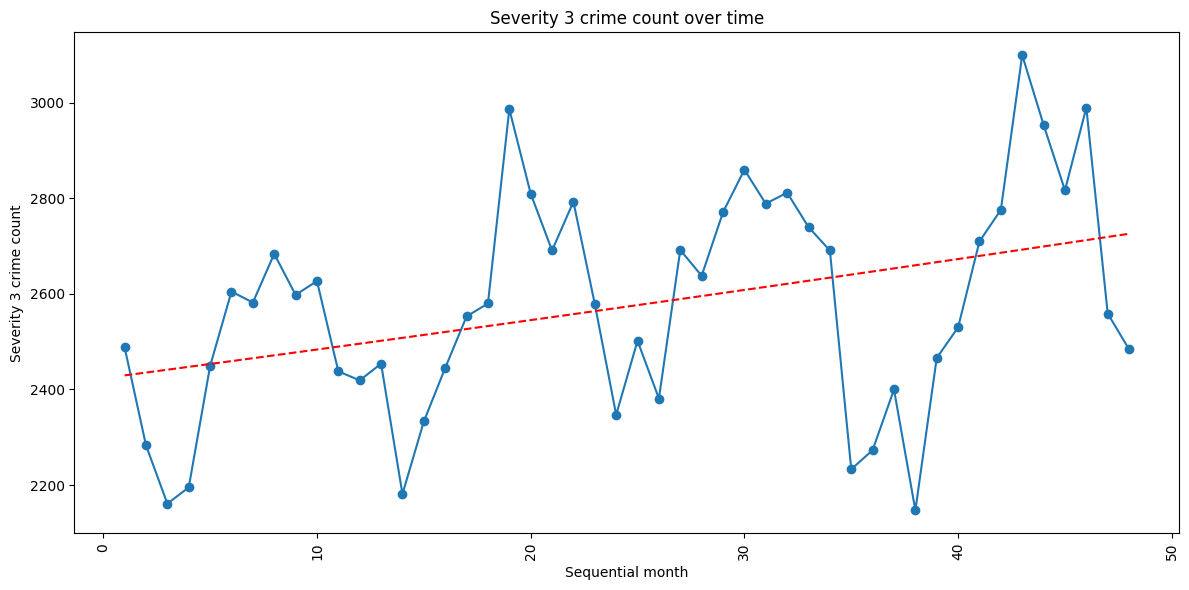

In [41]:
sev_model_fit(model_sev3, sev3, 3)

Our Poisson GLM shows a clear increasing trend, a statistically significant (although small) coefficient for `month_seq`. $e^{.0025} \approx 1.0025$ or a .25% increase, which translates to about 3% per year. Our p-value and z-score both show that the data is significant. We can conclusively answer that severe crime has increased since 2020. We don't however know the causes, population change, recordkeeping changes, etc. Let's apply the analysis to severity 1 and 2 crimes as well. 

In [42]:
model_sev2, sev2 = sev_model(2)
model_sev2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            crime_count   No. Observations:                   48
Model:                            GLM   Df Residuals:                       46
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -975.78
Date:                Sat, 13 Dec 2025   Deviance:                       1433.8
Time:                        01:18:20   Pearson chi2:                 1.45e+03
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.8671      0.003   2602.723      0.000       8.860       8.874
month_seq      0.0034      0.000     28.699      0.000       0.003       0.004
==============================================================================
"""

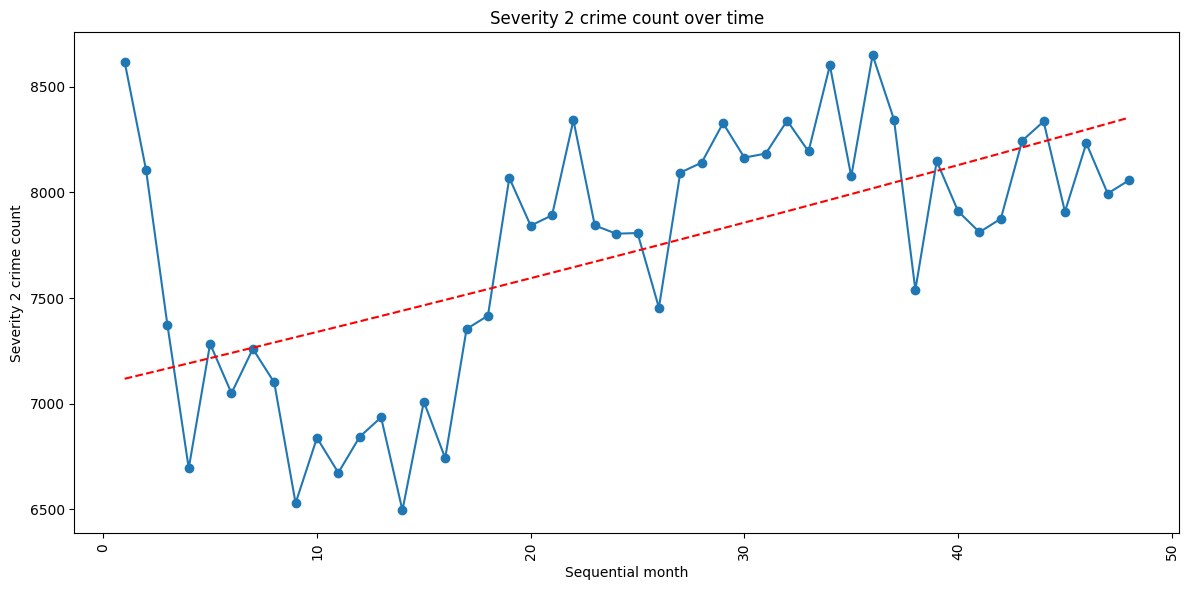

In [43]:
sev_model_fit(model_sev2, sev2, 2)

In [44]:
model_sev1, sev1 = sev_model(1)
model_sev1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            crime_count   No. Observations:                   48
Model:                            GLM   Df Residuals:                       46
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1947.4
Date:                Sat, 13 Dec 2025   Deviance:                       3416.5
Time:                        01:18:20   Pearson chi2:                 3.47e+03
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.0322      0.005   1562.132      0.000       8.022       8.042
month_seq      0.0043      0.000     24.156      0.000       0.004       0.005
==============================================================================
"""

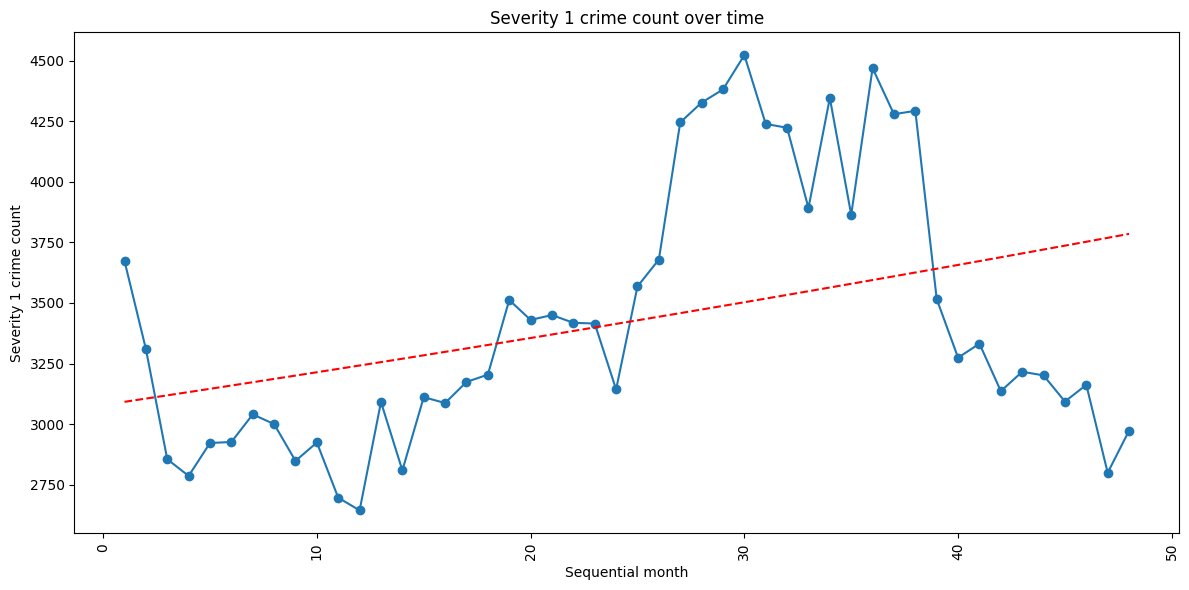

In [45]:
sev_model_fit(model_sev1, sev1, 1)

##### Initial conclusions and problems with this approach:

In severity 1 and 2 cases, we also see an increase with just a simple regression. However, when we investigate the graph of severity 1 crimes, there is a clear problem where the increase in crime looks temporary. Severity 2 looks like it had the most drastic increase. By inspecting log likelihoods, we find the most convincing model from severity 3, with decreasing effectiveness as severity decreases. A quick inspection below shows that Severity 1 crimes are dominated by identity theft, vandalism (both felony and misdemeanor), trespassing, and violations of orders, not necessarily violent crimes. We will ignore these for now and focus on violent crimes.

We are limited in our ability to add more variables to the model, because crime count, severity, and complexity are all interlinked. Severity and complexity are the properties of the crimes being committed and, as predictors, are functionally useless. We are somewhat limited in our data set, so we will explore another avenue.

Let's instead apply what we learned in the mine accident study to see if we can find a switch point in Severity 2 and 3 crimes.

In [46]:
# lacrime[lacrime['severity']==1][['severity', 'Crm Cd Desc']].sample(10)
lacrime[lacrime['severity'] == 1][['severity', 'Crm Cd Desc']].groupby('Crm Cd Desc', dropna = False).count().sort_values(by = 'severity', ascending = False).head(10).reset_index()

,Crm Cd Desc,severity
0,THEFT OF IDENTITY,55184
1,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",36429
2,VANDALISM - MISDEAMEANOR ($399 OR UNDER),16354
3,VIOLATION OF RESTRAINING ORDER,10169
4,TRESPASSING,7298
5,"LETTERS, LEWD - TELEPHONE CALLS, LEWD",6715
6,VIOLATION OF COURT ORDER,5570
7,"BUNCO, GRAND THEFT",5411
8,OTHER MISCELLANEOUS CRIME,3608
9,CONTEMPT OF COURT,2270


#### Switch point in Severity 2 and 3 crimes

Instead of taking the monthly number of crimes, let's split it up into weekly crimes. 

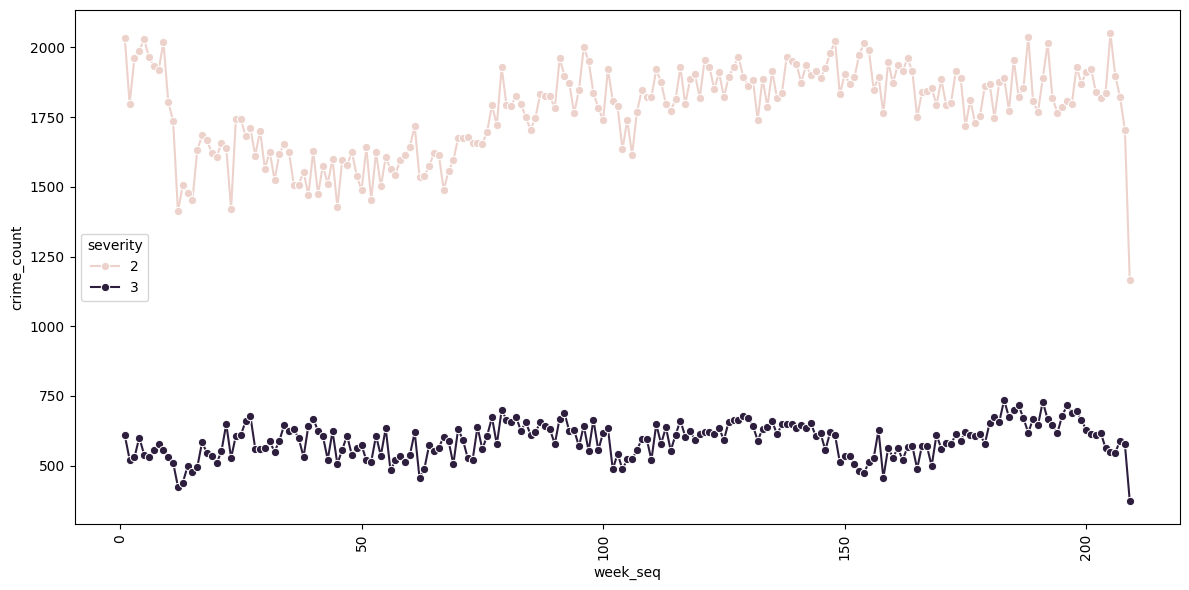

In [47]:
weekly_plot = lacrime.groupby([pd.Grouper(key = 'week_seq'), 'severity']).size().reset_index(name = 'crime_count')
fig,ax = plt.subplots(figsize = (12,6))
sns.lineplot(data = weekly_plot[weekly_plot['severity'] != 1], x = 'week_seq', y = 'crime_count', hue = 'severity',marker = 'o',  ax = ax)
# _=ax.set_xticks(60)
# ax.xaxis.set_major_locator(mpldates.MonthLocator(interval = 3))
# ax.xaxis.set_major_formatter(mpldates.DateFormatter('%Y-%m'))

plt.setp(ax.get_xticklabels(), rotation = 90)

plt.tight_layout()

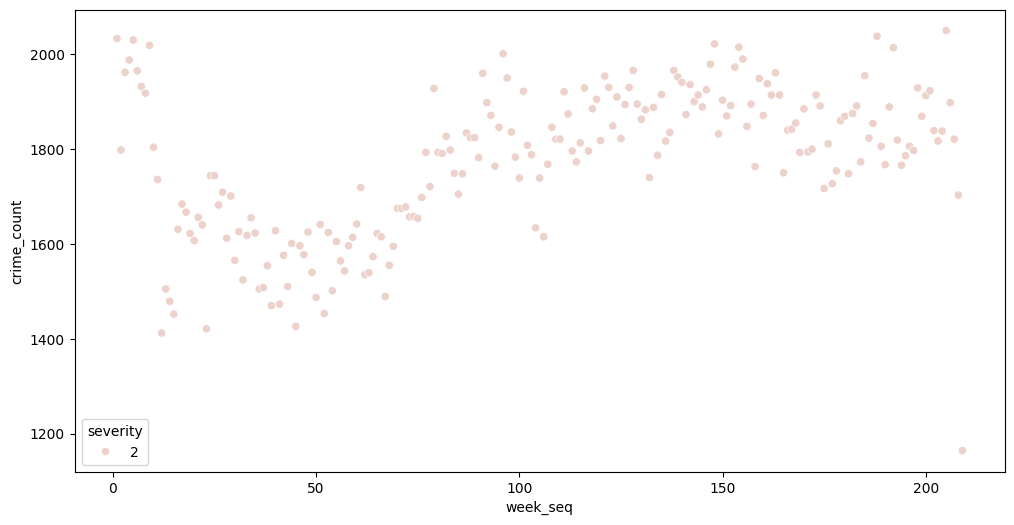

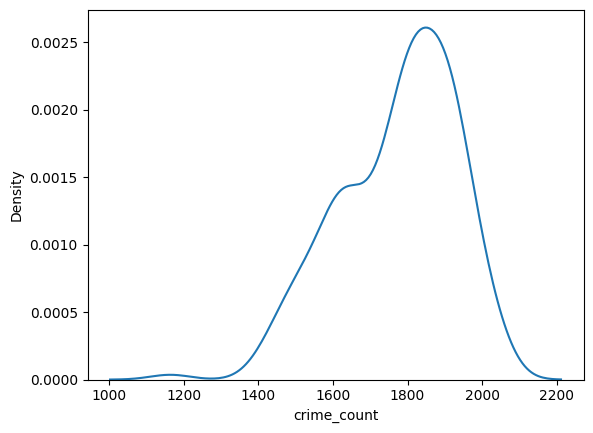

In [48]:
# weekly_plot_sev2 = weekly_plot[weekly_plot['severity'] == 2]
bayes_weekly_plot = weekly_plot[weekly_plot['severity'].isin([2])]

fig, ax = plt.subplots(figsize=(12,6))
sns.scatterplot(data = bayes_weekly_plot, x = 'week_seq', y = 'crime_count', hue = 'severity', marker = 'o', ax = ax)
plt.show()
sns.kdeplot(x = 'crime_count', data = bayes_weekly_plot)
plt.show()


In [49]:
print("Mean weekly crime count = {0:4.2f}".format(np.mean(bayes_weekly_plot.loc[:, 'crime_count'])))
print("Mean weekly crime count before 108 = {0:4.2f}".format(np.mean(bayes_weekly_plot.loc[bayes_weekly_plot['week_seq'] < 109, 'crime_count'])))
print("Mean weekly crime count after 108 = {0:4.2f}".format(np.mean(bayes_weekly_plot.loc[bayes_weekly_plot['week_seq'] >= 109, 'crime_count'])))

Mean weekly crime count = 1773.08
Mean weekly crime count before 108 = 1689.31
Mean weekly crime count after 108 = 1862.65


Sampling: [crimes, early_rate, late_rate, switchpoint]


array([[<Axes: title={'center': 'switchpoint'}>,
        <Axes: title={'center': 'late_rate'}>,
        <Axes: title={'center': 'early_rate'}>]], dtype=object)

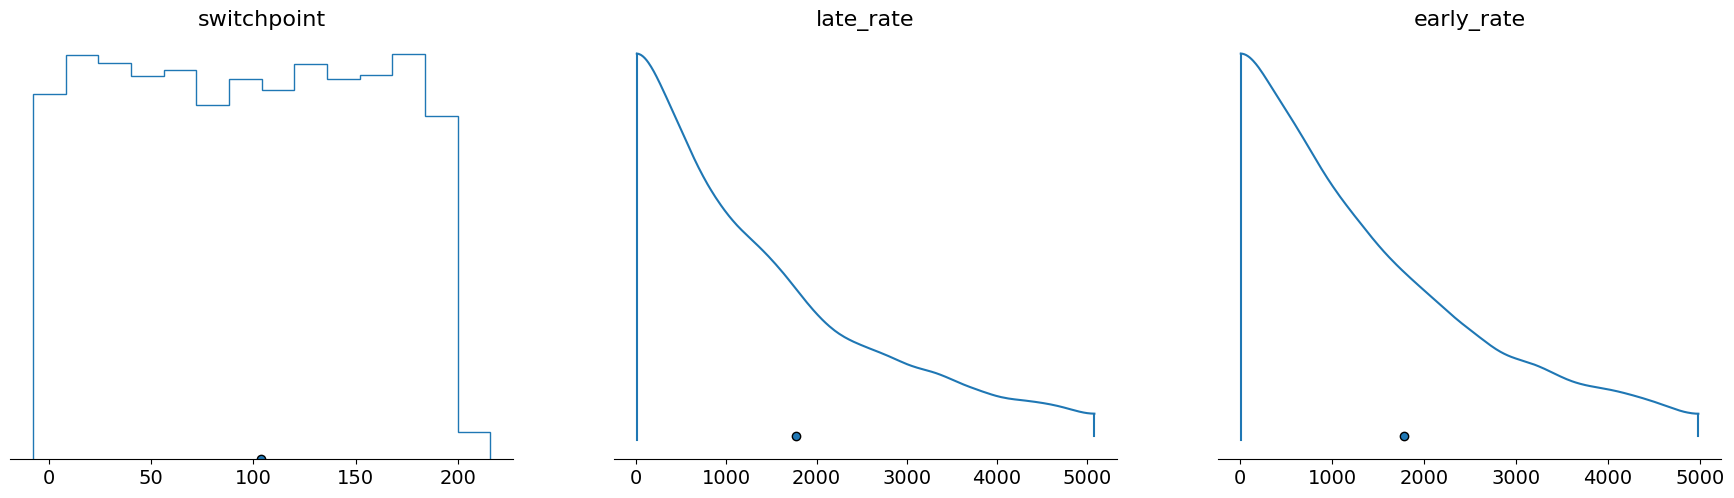

In [50]:
week_seq = bayes_weekly_plot['week_seq'].values
crime_count = bayes_weekly_plot['crime_count'].values

with pymc.Model() as sev_bayes:
    switchpoint = pymc.DiscreteUniform("switchpoint", lower=0, upper = len(crime_count)-1)
    n_for_exp = np.mean(bayes_weekly_plot.loc[:, 'crime_count'])
    early_rate = pymc.Exponential("early_rate", 1/n_for_exp)
    late_rate = pymc.Exponential("late_rate", 1/n_for_exp) ## pymc exponential function is inverse

    rate = pymc.math.switch(week_seq < switchpoint, early_rate, late_rate)

    sev2crimes = pymc.Poisson("crimes", rate, observed = bayes_weekly_plot['crime_count'])
    
with sev_bayes:
    prior_checks = pymc.sample_prior_predictive(samples = 5000)
prior_checks.keys()

az.plot_density(prior_checks, group = 'prior')

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [early_rate, late_rate]
>Metropolis: [switchpoint]


Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 4 seconds.


array([[<Axes: title={'center': 'switchpoint'}>,
        <Axes: title={'center': 'switchpoint'}>],
       [<Axes: title={'center': 'early_rate'}>,
        <Axes: title={'center': 'early_rate'}>],
       [<Axes: title={'center': 'late_rate'}>,
        <Axes: title={'center': 'late_rate'}>]], dtype=object)

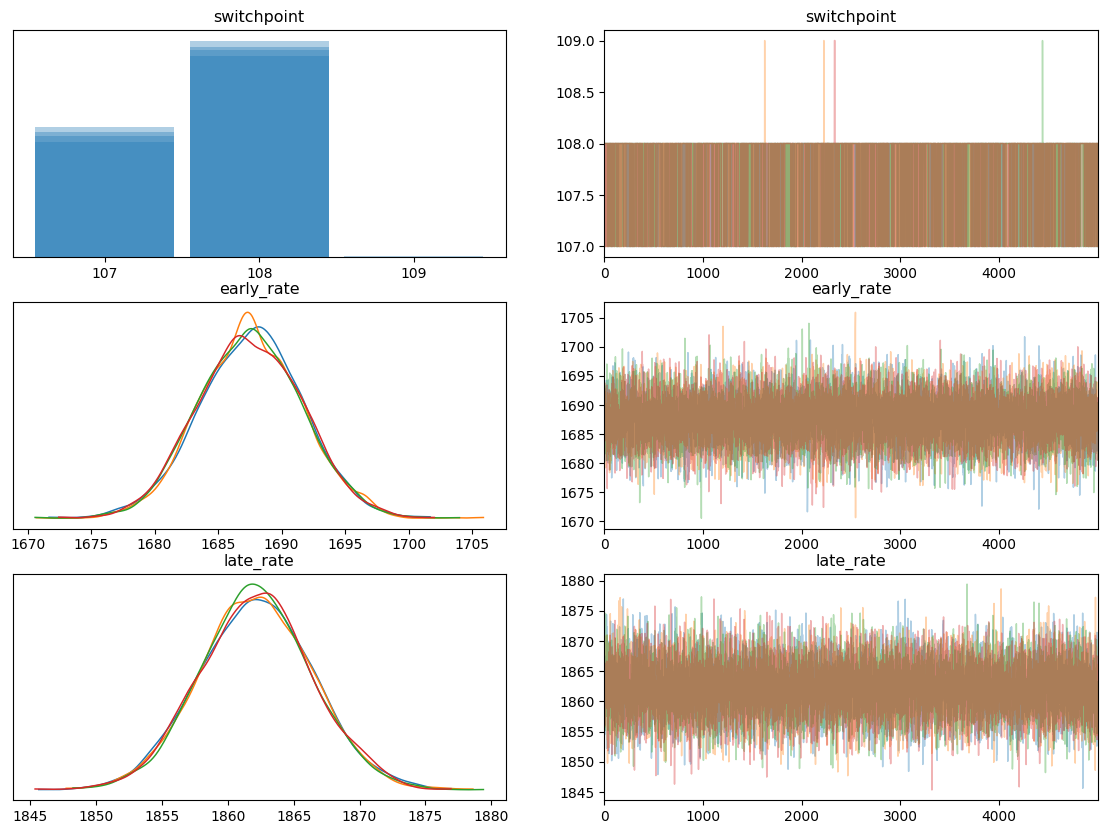

In [51]:
RNDSEED = 5555
with sev_bayes:
    sev_samples = pymc.sample(draws = 5000, return_inferencedata = True, step = [pymc.NUTS(target_accept=0.95, max_treedepth=60)], random_seed = RNDSEED)
az.plot_trace(sev_samples, compact=False, figsize = (14,10))


             mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
switchpoint      0.007    0.005    4499.0    4007.0    1.0
early_rate       0.035    0.025   13100.0   11899.0    1.0
late_rate        0.037    0.026   13624.0   12403.0    1.0


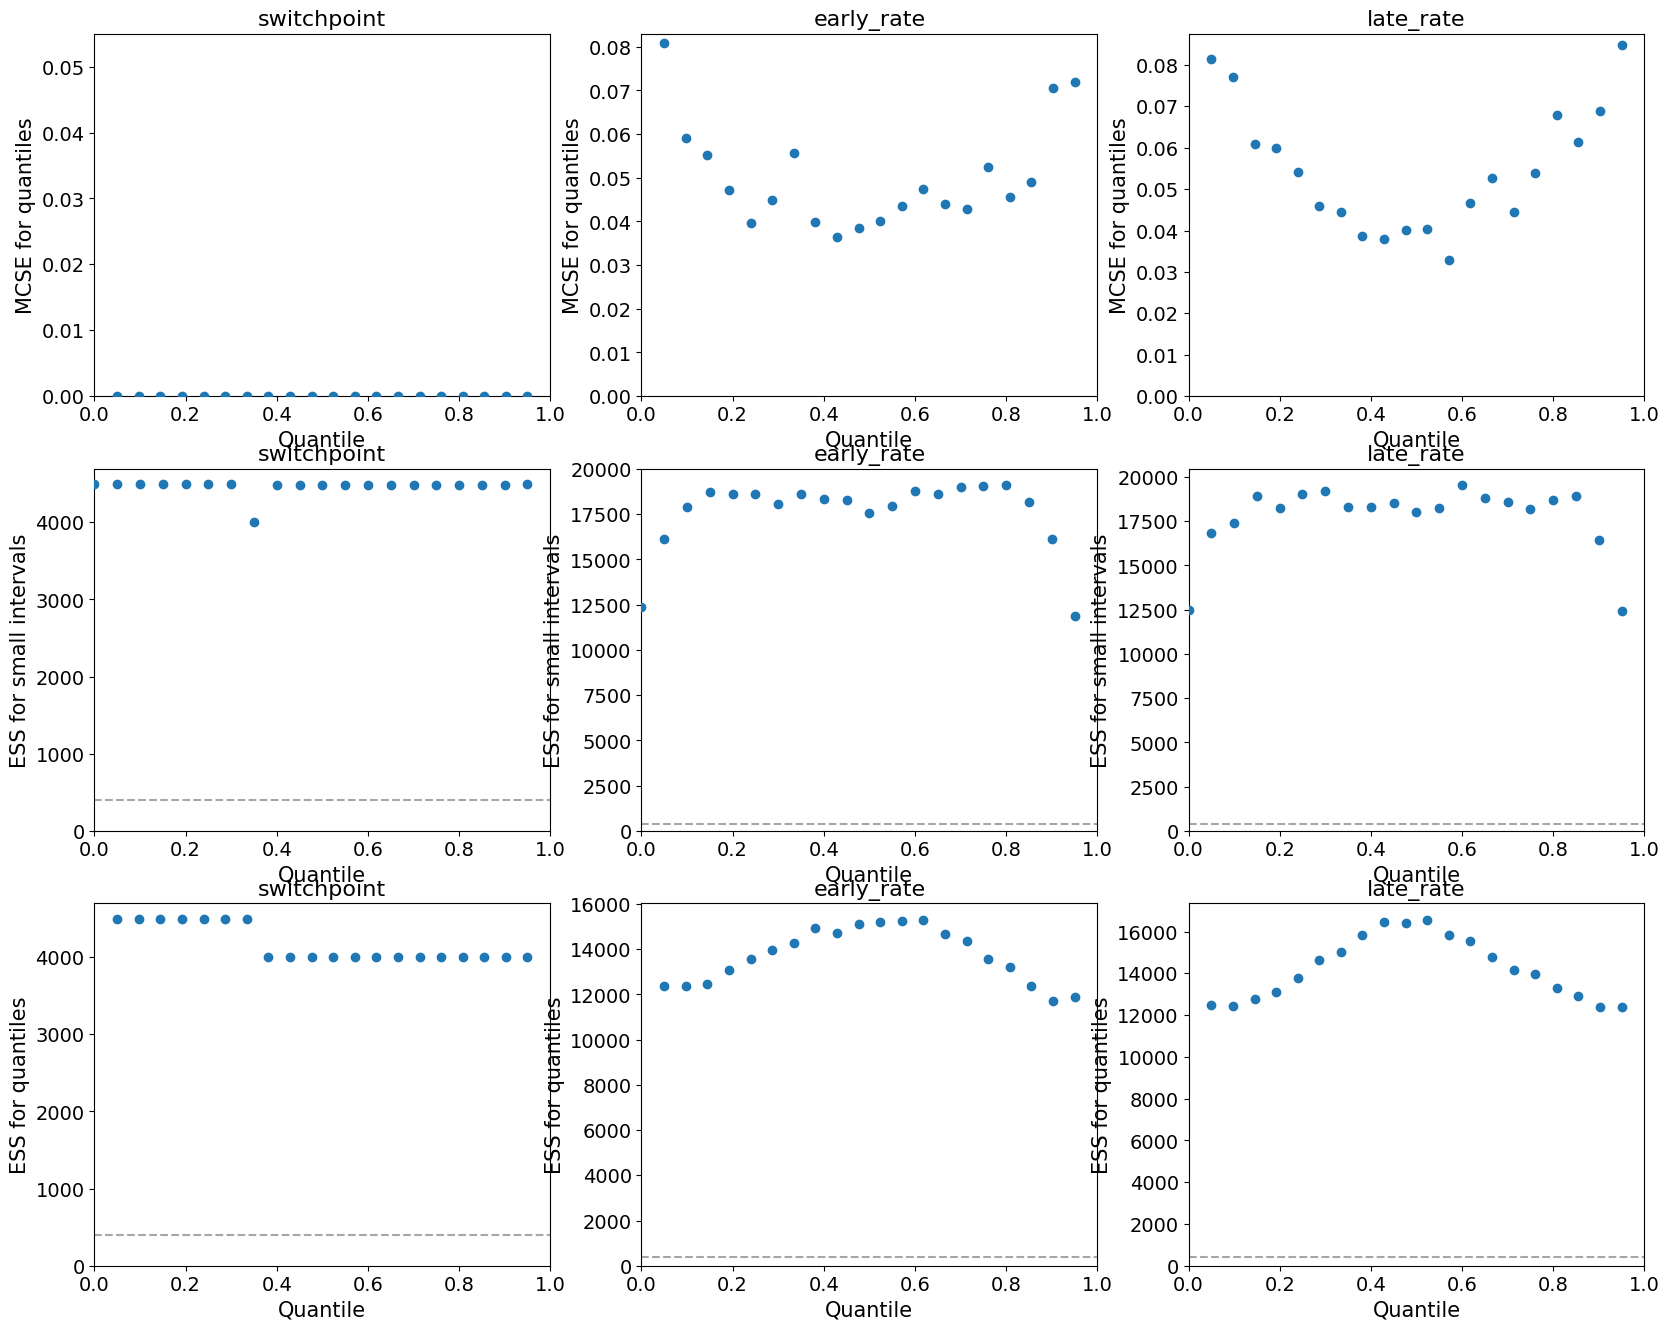

In [52]:
print(az.summary(sev_samples, kind = "diagnostics"))


_,ax = plt.subplots(3,3, figsize=(20,16))
az.plot_mcse(sev_samples, ax=ax[0])
az.plot_ess(sev_samples, kind="local", ax=ax[1]);
az.plot_ess(sev_samples, kind="quantile", ax=ax[2]);

Although our results weren't as clean as the mine example, we did see a significant difference. Switchpoint is locked onto weeks 108, which is late January 2022. Our ESS, MCSE, all pretty much point to certainty. Early and late rate metrics do have decent confidence. 

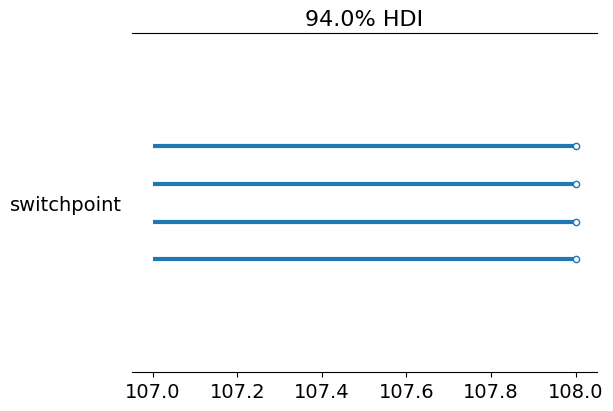

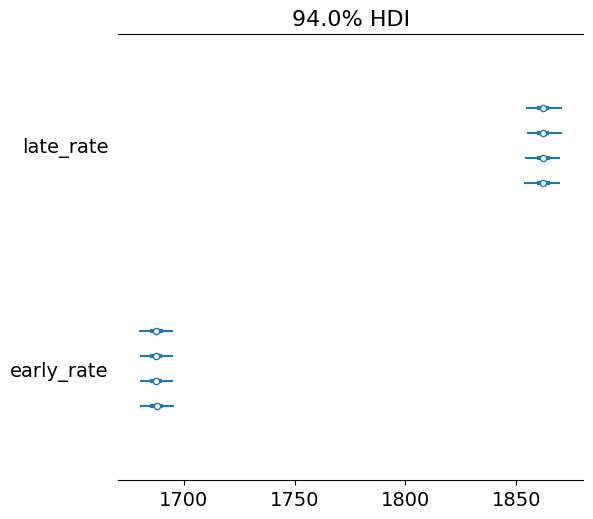

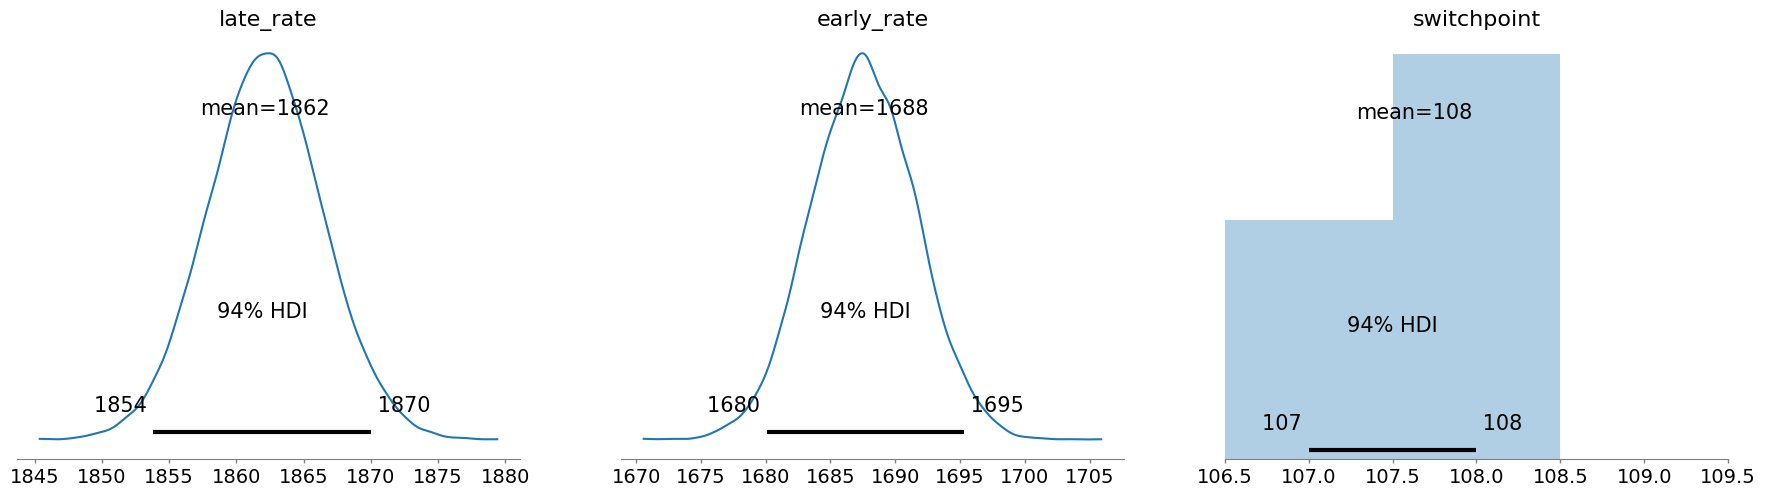

In [53]:
az.plot_forest(sev_samples, var_names = 'switchpoint')
az.plot_forest(sev_samples, var_names=['late_rate', 'early_rate']);
plt.show()
az.plot_posterior(sev_samples, var_names=['late_rate', 'early_rate', 'switchpoint']); 
plt.show()

This actually looks pretty solid for once, so we have one thing, something happenend in week 108 (late january). not bad not bad!! 10% increase in Sev 2

##### maybe build hierarchical model based on area

Sampling: [crimes]


<Axes: xlabel='crimes'>

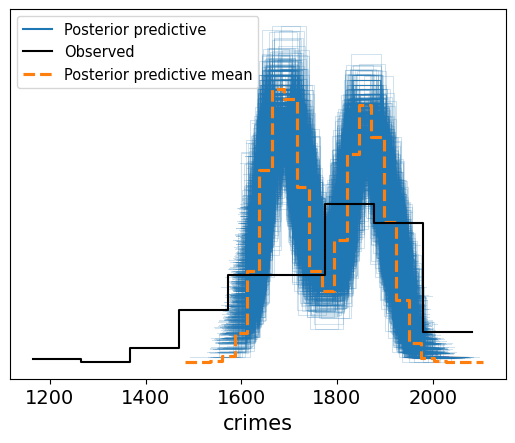

In [54]:
early_mask = bayes_weekly_plot['week_seq'] < 108
late_mask = bayes_weekly_plot['week_seq'] >= 108

with sev_bayes:
    pymc.sample_posterior_predictive(sev_samples, extend_inferencedata = True)
az.plot_ppc(sev_samples, num_pp_samples=1000)

Our prediction has two large peaks. The late rate fit looks OK, but the peak is too tall. The late rate variance is underestimated. On the other hand, the early rate is actually a bad fit. We will take a closer look at the early rate in subsequent plots and perhaps change our likelihood function.

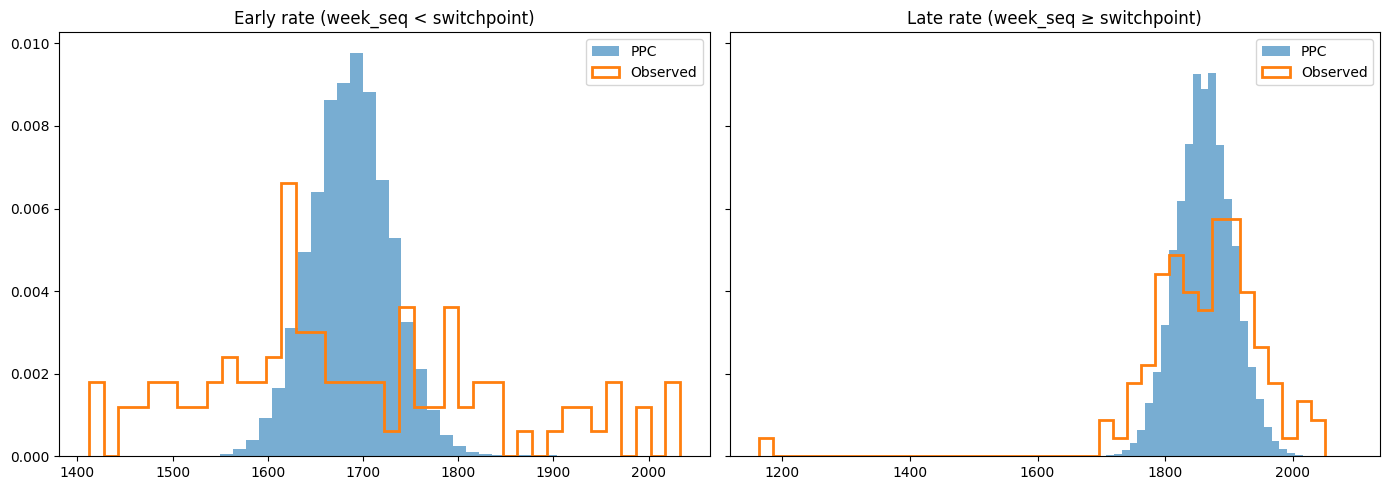

In [55]:
switchpoint_hat = sev_samples.posterior['switchpoint'].mean().item()
switchpoint_hat

crimes_obs = sev_samples.observed_data['crimes'].values # get obsereved data
crimes_ppc = sev_samples.posterior_predictive['crimes'].values
crimes_ppc_flat = crimes_ppc.reshape(-1, crimes_ppc.shape[-1]) # reshape data

week_seq = bayes_weekly_plot['week_seq'].values

early_mask = week_seq < switchpoint_hat
late_mask  = week_seq >= switchpoint_hat

# observed
crimes_obs_early = crimes_obs[early_mask]
crimes_obs_late  = crimes_obs[late_mask]

# posterior predictive
crimes_ppc_early = crimes_ppc_flat[:, early_mask].ravel()
crimes_ppc_late  = crimes_ppc_flat[:, late_mask].ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(crimes_ppc_early, bins=40, density=True, alpha=0.6, label='PPC')
axes[0].hist(
    crimes_obs_early,
    bins=40,
    density=True,
    histtype='step',
    linewidth=2,
    label='Observed'
)
axes[0].set_title('Early rate (week_seq < switchpoint)')
axes[0].legend()

axes[1].hist(crimes_ppc_late, bins=40, density=True, alpha=0.6, label='PPC')
axes[1].hist(
    crimes_obs_late,
    bins=40,
    density=True,
    histtype='step',
    linewidth=2,
    label='Observed'
)
axes[1].set_title('Late rate (week_seq ≥ switchpoint)')
axes[1].legend()

plt.tight_layout()
plt.show()


Here we see that the early rate does not appear to be one Poisson data set but perhaps multiple rates. The late rate may be a negative binomial. 

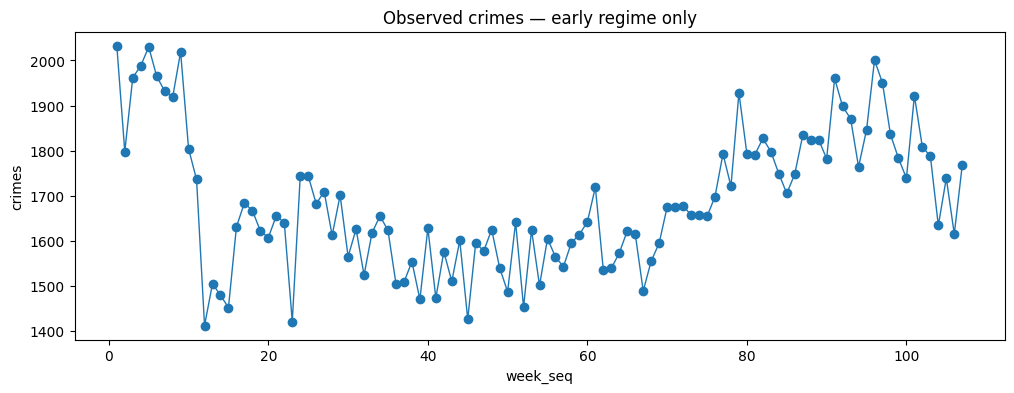

In [56]:
T = sev_samples.observed_data['crimes'].shape[0]
idx = np.arange(T)
early_idx = idx[early_mask]

plt.figure(figsize=(12,4))
plt.plot(week_seq[early_mask], crimes_obs[early_mask], marker='o', linewidth=1)
plt.title("Observed crimes — early regime only")
plt.xlabel("week_seq")
plt.ylabel("crimes")
plt.show()


Sampling: [alpha, crimes, early_rate, late_rate, switchpoint]


array([[<Axes: title={'center': 'switchpoint'}>,
        <Axes: title={'center': 'late_rate'}>,
        <Axes: title={'center': 'early_rate'}>]], dtype=object)

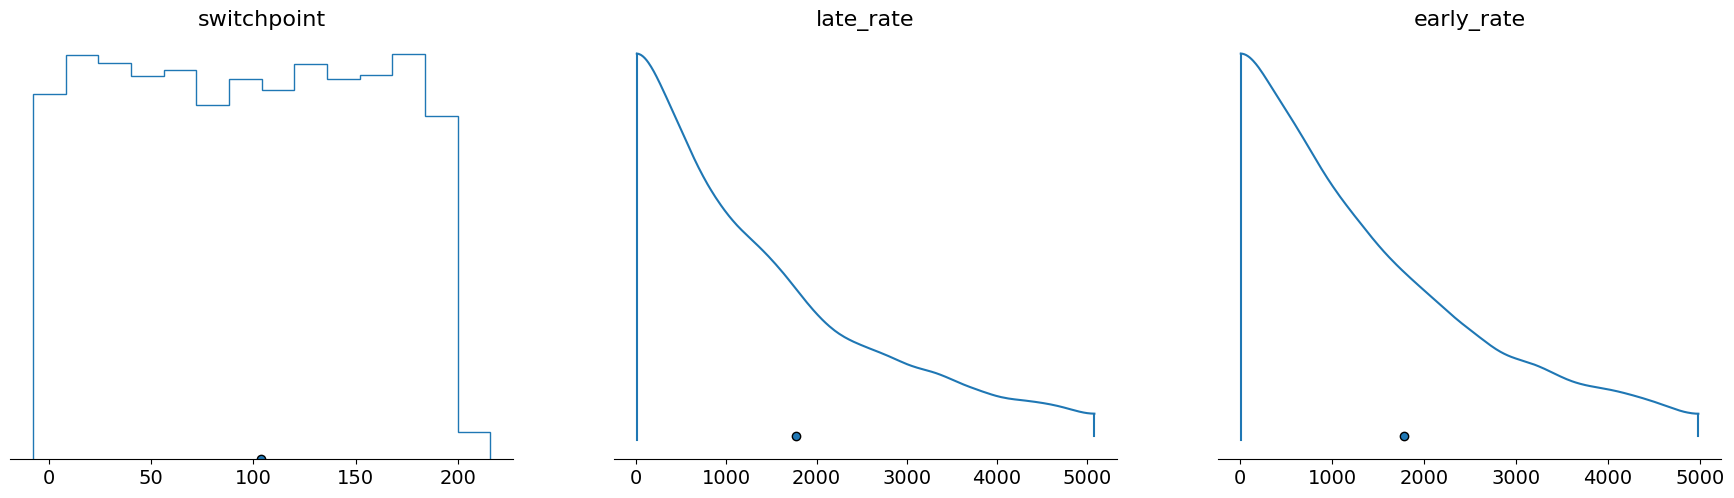

In [ ]:
week_seq = bayes_weekly_plot['week_seq'].values
crime_count = bayes_weekly_plot['crime_count'].values
T = len(crime_count)
t = np.arange(T)

# we can try to calculate alpha from the data (Suggestion from Chat GPT LLM)
late = crime_count[t >= int(round(78))]
m = late.mean()
v = late.var()
alpha_hat = m*m / (v - m) if v > m else np.inf
m, v, alpha_hat


with pymc.Model() as sev_bayes2:
    switchpoint = pymc.DiscreteUniform(
        "switchpoint",
        lower=0,
        upper=T - 1
    )

    n_for_exp = crime_count.mean()
    early_rate = pymc.Exponential("early_rate", 1 / n_for_exp)
    late_rate  = pymc.Exponential("late_rate", 1 / n_for_exp)

    # alpha = pymc.Gamma("alpha", alpha=10, beta=0.02)  # mean = 20/0.02 = 1000
    alpha = pymc.Gamma("alpha", alpha=5, beta=5/alpha_hat)  # mean ~ alpha_hat

    
    rate = pymc.math.switch(t < switchpoint, early_rate, late_rate)

    sev2crimes2 = pymc.NegativeBinomial(
        "crimes",
        mu=rate,
        alpha=alpha,
        observed=crime_count
    )

with sev_bayes2:
    prior_checks2 = pymc.sample_prior_predictive(samples=5000)

az.plot_density(prior_checks, group="prior")

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [early_rate, late_rate, alpha]
>Metropolis: [switchpoint]


Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 5 seconds.


array([[<Axes: title={'center': 'switchpoint'}>,
        <Axes: title={'center': 'switchpoint'}>],
       [<Axes: title={'center': 'early_rate'}>,
        <Axes: title={'center': 'early_rate'}>],
       [<Axes: title={'center': 'late_rate'}>,
        <Axes: title={'center': 'late_rate'}>],
       [<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>]], dtype=object)

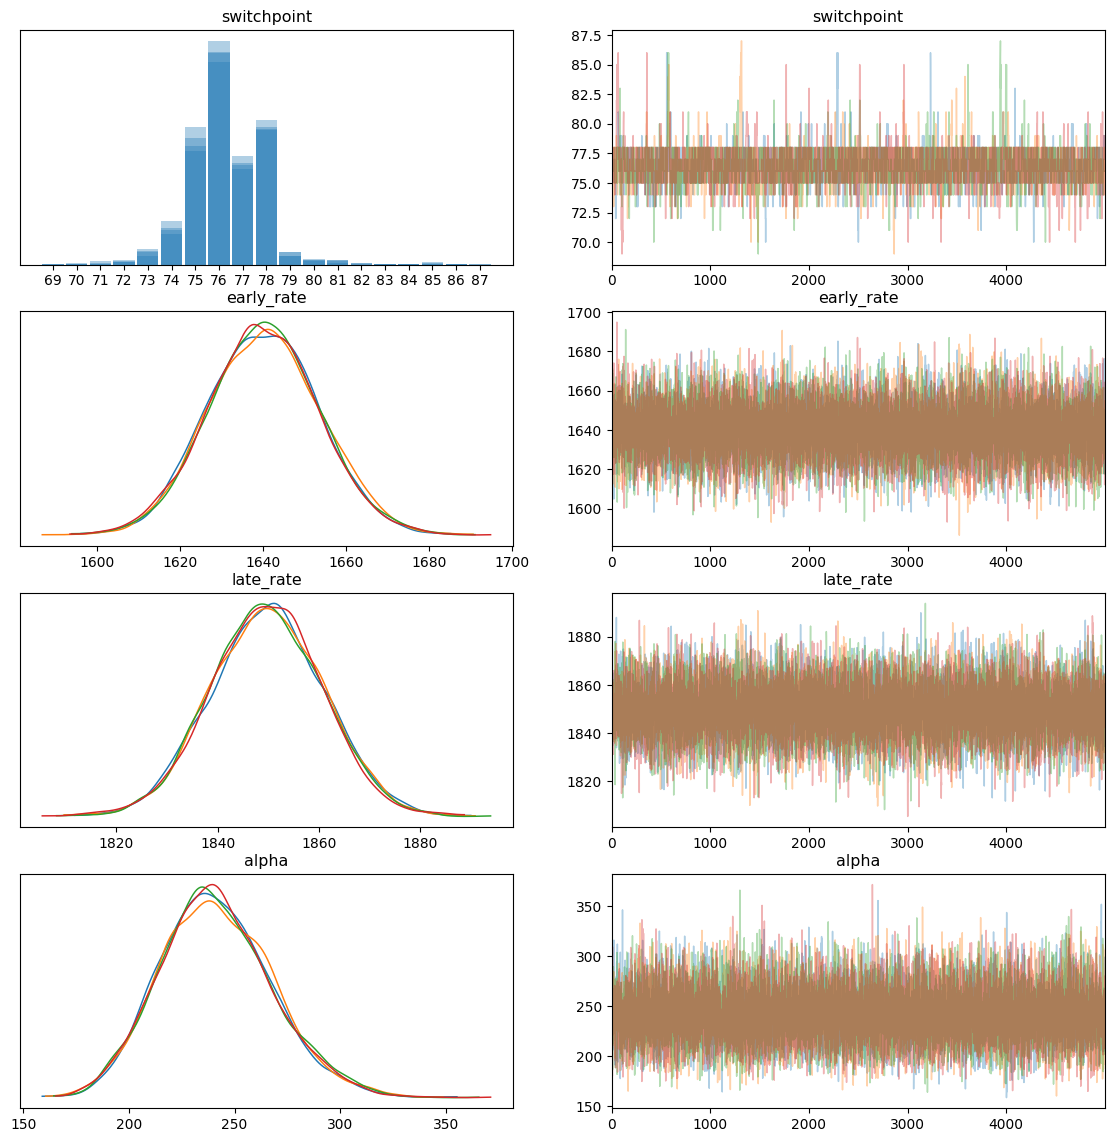

In [59]:
# RNDSEED = 5555
with sev_bayes2:
    # sev_samples2 = pymc.sample(draws = 5000, return_inferencedata = True, step = [pymc.NUTS(target_accept=0.95, max_treedepth=60)], random_seed = RNDSEED)
    sev_samples2 = pymc.sample(draws = 5000, return_inferencedata = True, step = [pymc.NUTS(target_accept=0.95, max_treedepth=60)])
az.plot_trace(sev_samples2, compact=False, figsize = (14,14))

             mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
switchpoint      0.029    0.021    3262.0    2685.0    1.0
early_rate       0.105    0.075   16096.0   13240.0    1.0
late_rate        0.086    0.061   16471.0   13159.0    1.0
alpha            0.201    0.144   17546.0   13419.0    1.0


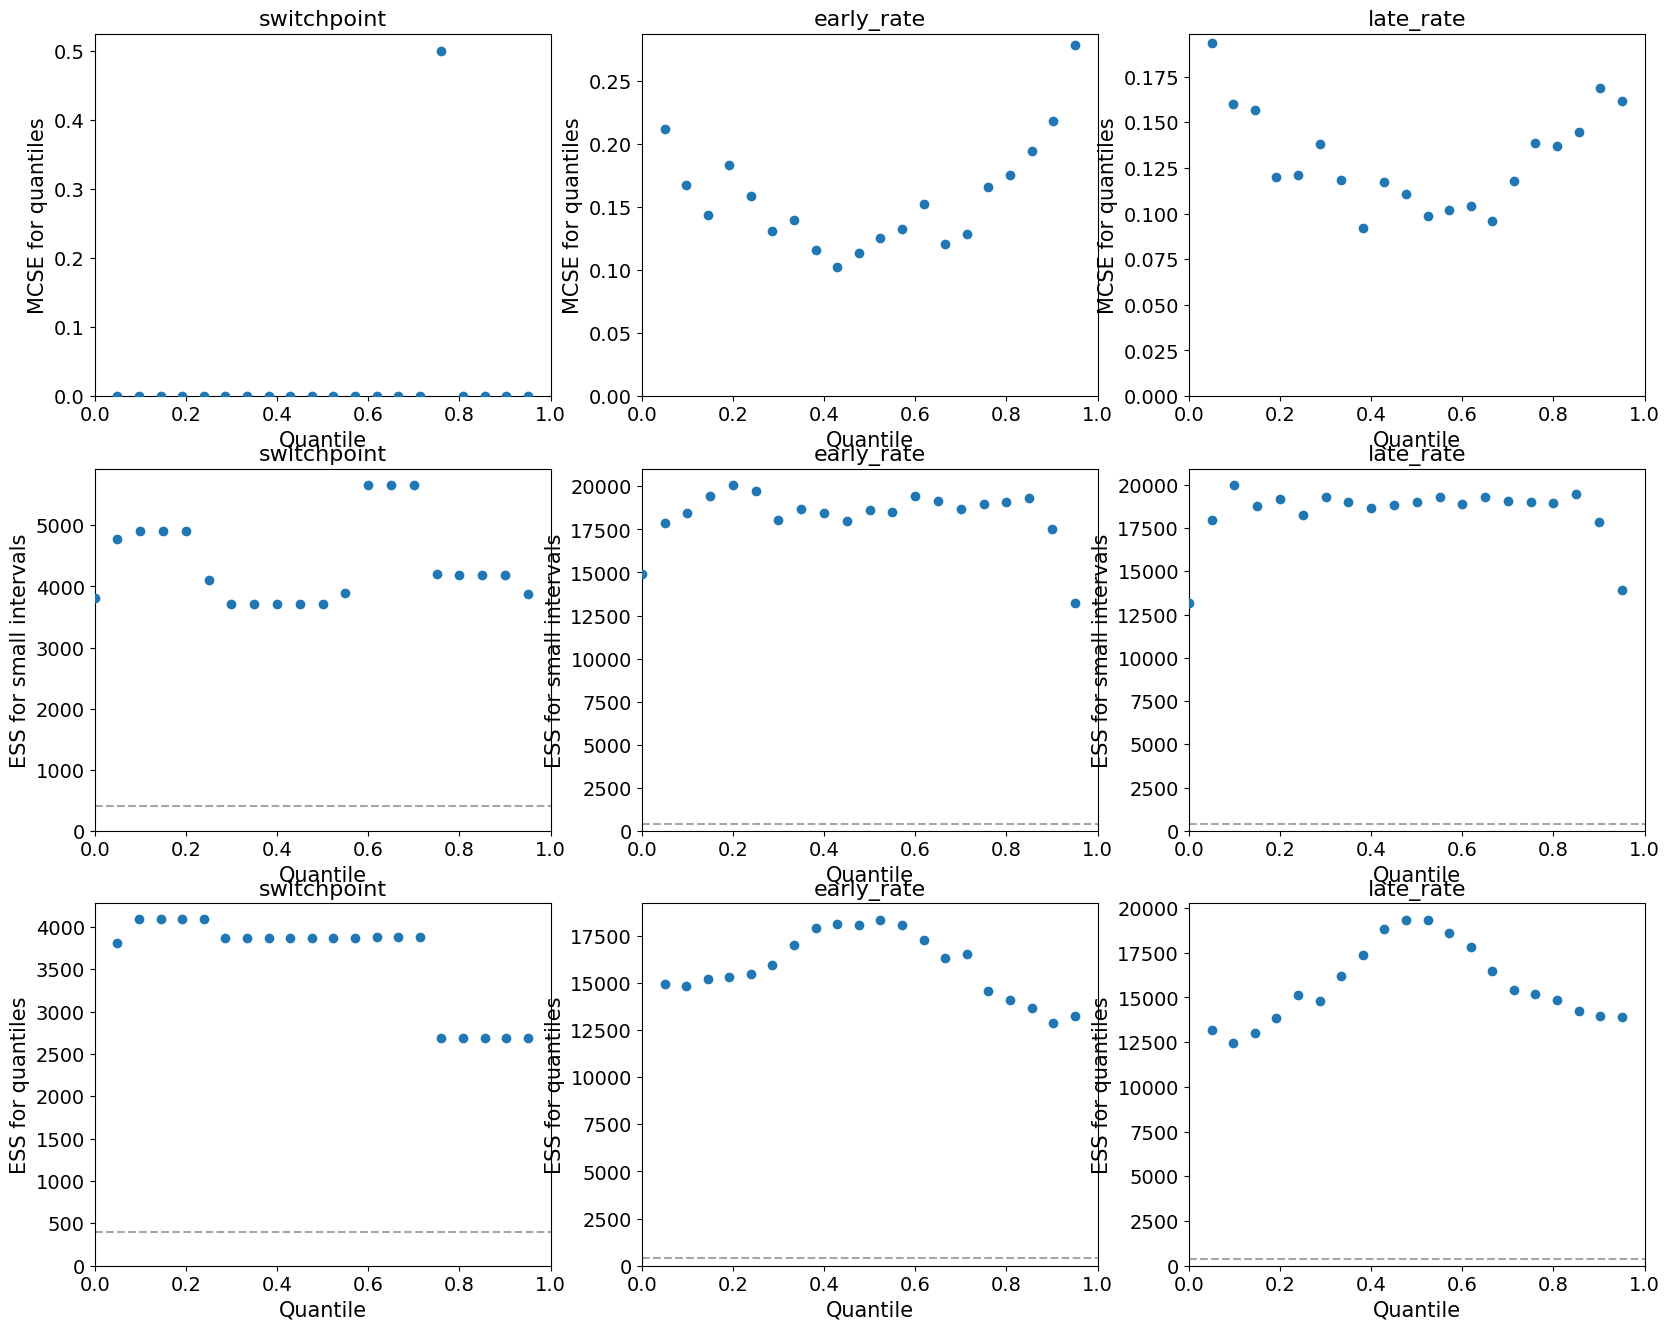

In [60]:
print(az.summary(sev_samples2, kind = "diagnostics"))

_,ax = plt.subplots(3,3, figsize=(20,16))
az.plot_mcse(sev_samples2, ax=ax[0])
az.plot_ess(sev_samples2, kind="local", ax=ax[1]);
az.plot_ess(sev_samples2, kind="quantile", ax=ax[2]);

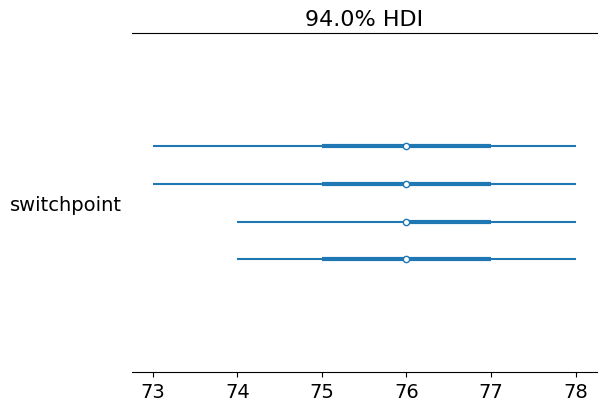

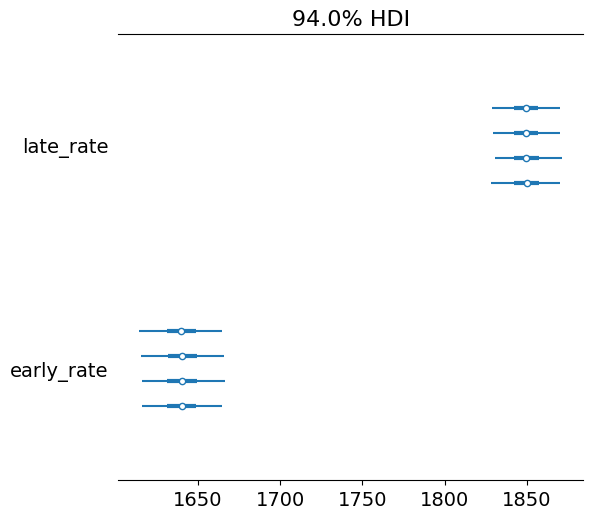

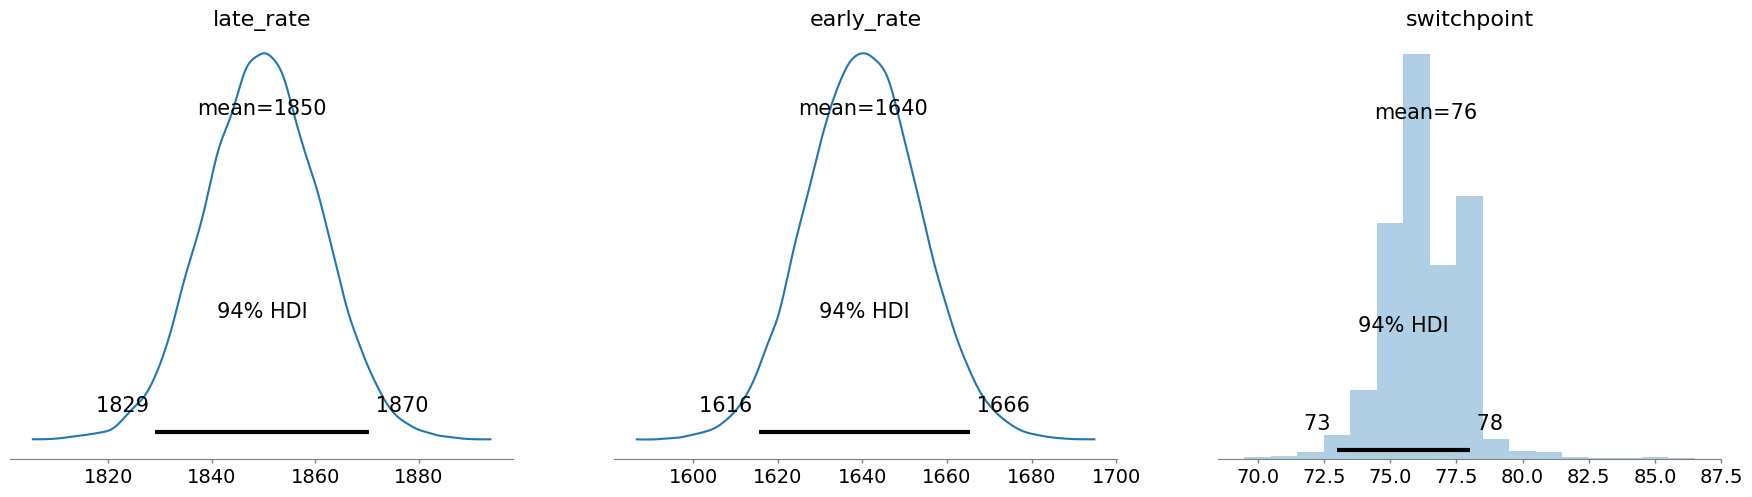

In [61]:
az.plot_forest(sev_samples2, var_names = 'switchpoint')
az.plot_forest(sev_samples2, var_names=['late_rate', 'early_rate']);
plt.show()
az.plot_posterior(sev_samples2, var_names=['late_rate', 'early_rate', 'switchpoint']); 
plt.show()

Sampling: [crimes]


<Axes: xlabel='crimes'>

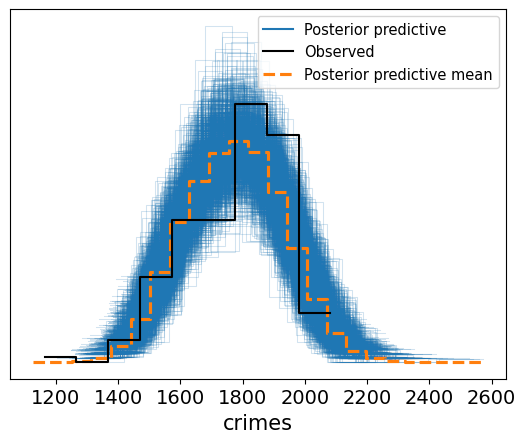

In [62]:
with sev_bayes2:
    pymc.sample_posterior_predictive(sev_samples2, extend_inferencedata = True)
az.plot_ppc(sev_samples2, num_pp_samples=1000)

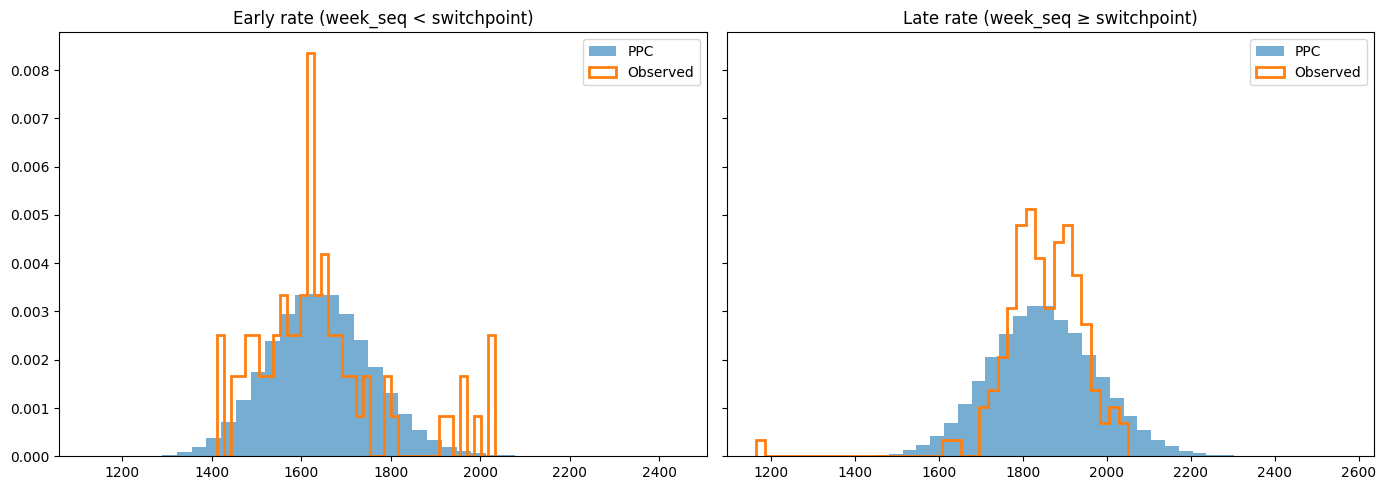

In [63]:
switchpoint_hat2 = sev_samples2.posterior['switchpoint'].mean().item()
early_mask2 = t < switchpoint_hat2
late_mask2  = t >= switchpoint_hat2

crimes_obs2 = sev_samples2.observed_data['crimes'].values  # observed data
crimes_ppc2 = sev_samples2.posterior_predictive['crimes'].values
crimes_ppc_flat2 = crimes_ppc2.reshape(-1, crimes_ppc2.shape[-1])  # reshape data

T = len(crimes_obs2)
t = np.arange(T)
week_seq2 = bayes_weekly_plot['week_seq'].values


# observed
crimes_obs_early2 = crimes_obs2[early_mask2]
crimes_obs_late2  = crimes_obs2[late_mask2]

# posterior predictive
crimes_ppc_early2 = crimes_ppc_flat2[:, early_mask2].ravel()
crimes_ppc_late2  = crimes_ppc_flat2[:, late_mask2].ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(crimes_ppc_early2, bins=40, density=True, alpha=0.6, label='PPC')
axes[0].hist(
    crimes_obs_early2,
    bins=40,
    density=True,
    histtype='step',
    linewidth=2,
    label='Observed'
)
axes[0].set_title('Early rate (week_seq < switchpoint)')
axes[0].legend()

axes[1].hist(crimes_ppc_late2, bins=40, density=True, alpha=0.6, label='PPC')
axes[1].hist(
    crimes_obs_late2,
    bins=40,
    density=True,
    histtype='step',
    linewidth=2,
    label='Observed'
)
axes[1].set_title('Late rate (week_seq ≥ switchpoint)')
axes[1].legend()

plt.tight_layout()
plt.show()


We identified 

In [64]:
weekly_plot_area = lacrime.groupby(['week_seq', 'severity', 'AREA NAME']).size().reset_index(name = 'crime_count')

4. crime type variance
6. build the time series

In [65]:
lacrime['Date Rptd'].max()

Timestamp('2025-03-28 00:00:00')

In [66]:
lacrime['AREA NAME'].fillna('n/a').value_counts().head(10)

AREA NAME
Central        46642
77th Street    41835
Southwest      41508
Pacific        36997
Hollywood      35134
Southeast      33359
Olympic        32553
N Hollywood    31861
Wilshire       31837
Newton         30639
Name: count, dtype: int64

In [67]:
# lacrime[lacrime['AREA NAME'] != lacrime['AREA']]